# Diabetes Hospital Readmission Within 30 Days

## End-to-End Machine Learning Pipeline

The complete workflow of this project is designed to predict whether a diabetic patient will be readmitted to the hospital within 30 days.

### Project Pipeline

**Problem Definition & Objective**  
↓  
Define the task as an **imbalanced binary classification problem**:

- Class `1` → Readmitted within `<30 days`
- Class `0` → Readmitted after `>30 days` or `NO` readmission

↓  

**Environment Setup & Libraries**  
↓  
Import and configure the main libraries:

`Pandas` → `NumPy` → `SciPy` → `Matplotlib` → `Seaborn` →  
`Scikit-learn` → `XGBoost` → `LightGBM` → `Imbalanced-learn` → `Joblib`

↓  

**Dataset Loading & Understanding**  
↓  
Load the **Diabetes 130-US Hospitals Dataset (1999–2008)**  
↓  
Original dataset contains approximately **101,766 hospital encounters**  
↓  
Inspect:

- Dataset shape
- Data types
- Feature meanings
- Target distribution
- Numerical and categorical features

↓  

**Data Cleaning**  
↓  
Check and handle:

`Missing Values (?) / NaN`  
↓  
Drop highly-missing `weight` feature  
↓  
Preserve meaningful missing categorical values  
↓  
Clean invalid gender values  
↓  
Check duplicated records  
↓  
Review incorrect / inconsistent values  
↓  
Exclude death and hospice discharge encounters  
↓  
Inspect potential outliers using IQR and boxplots  
↓  
Keep clinically meaningful extreme values instead of removing them automatically

↓  

**Exploratory Data Analysis (EDA)**  
↓  
Perform:

`Summary Statistics`  
↓  
`Target Distribution / Class Balance`  
↓  
`Numerical Feature Distributions`  
↓  
`Histograms`  
↓  
`Boxplots`  
↓  
`Correlation Heatmap`  
↓  
`Feature vs Target Analysis`

↓  

**Leakage-Safe Patient-Level Data Splitting**  
↓  
Use `patient_nbr` only as a grouping variable  
↓  
Apply **GroupShuffleSplit**  
↓  

`Training Set`  
+  
`Validation Set`  
+  
`Untouched Test Set`

↓  
Ensure that the same patient never appears in more than one dataset split

↓  

**Initial Feature Engineering**  
↓  
Convert ICD diagnosis codes:

`diag_1` + `diag_2` + `diag_3`  
↓  
Map raw diagnosis codes into broader medical diagnosis groups

↓  

**Data Preprocessing**  
↓  

Categorical Features  
→ `OneHotEncoder`

Numerical Features  
→ `StandardScaler`

↓  
Fit preprocessing components on **Training data only**  
↓  
Transform Validation and Test data using the fitted preprocessing objects

↓  

**Training-Only Feature Importance Review**  
↓  
Use tree-based feature importance to inspect the most informative processed features  
↓  
Keep the complete feature set for the original baseline models

↓  

# Baseline Model Building

Train at least three machine-learning algorithms:

`Logistic Regression`  
↓  
`Random Forest`  
↓  
`XGBoost`

↓  

**Validation-Based Threshold Optimization**  
↓  
Test multiple probability thresholds  
↓  
Select thresholds using **Class-1 F1-score on Validation data only**

↓  

**Baseline Model Evaluation**  
↓  
Evaluate using:

`Accuracy`  
+  
`Precision`  
+  
`Recall`  
+  
`F1-score`  
+  
`ROC-AUC`  
+  
`PR-AUC`

↓  

Generate:

- Model comparison table
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve
- Feature Importance
- XGBoost SHAP-style explanation

↓  

# Advanced Imbalance Handling & Model Optimization

Because the `<30-day readmission` class is the minority class, several additional experiments are performed.

---

### Experiment 1 — Weighted XGBoost

Calculate:

`scale_pos_weight = Majority Class / Minority Class`

↓  
Train Weighted XGBoost  
↓  
Validation Threshold Optimization  
↓  
Best Validation F1 ≈ **0.2953**

---

### Experiment 2 — Balanced LightGBM

Train LightGBM with:

`class_weight = balanced`

↓  
Threshold Optimization  
↓  
Best Validation F1 ≈ **0.2936**

---

### Experiment 3 — Full SMOTE + XGBoost

Apply SMOTE to the **Training set only**

↓  

Minority Class Oversampling  
↓  
Balanced Training Dataset  
↓  
XGBoost Training  
↓  
Probability Distribution Analysis  
↓  
Threshold Optimization

↓  
Best Validation F1 ≈ **0.2829**

↓  
Full SMOTE is not selected

---

# Additional Feature Engineering

Create new domain-inspired features:

`total_previous_visits`

`hospital_utilization`

`total_clinical_activity`

`medications_per_day`

`labs_per_day`

`procedures_per_day`

`diagnosis_burden`

`has_inpatient_history`

`has_emergency_history`

`has_outpatient_history`

↓  

Build a new preprocessing pipeline for the engineered dataset

↓  

### Experiment 4 — XGBoost + Engineered Features

Train XGBoost  
↓  
Threshold Optimization  
↓  
Best Validation F1 ≈ **0.2955**

---

### Experiment 5 — Weighted XGBoost + Engineered Features

Feature Engineering  
+  
Class Weighting

↓  
Threshold Optimization  
↓  
Best Validation F1 ≈ **0.2955**

---

# Grouped Cross-Validation & Hyperparameter Tuning

Use:

**StratifiedGroupKFold**

↓  

Preserve class balance  
+  
Prevent the same patient from appearing in different CV folds

↓  

### Experiment 6 — Tuned XGBoost

`RandomizedSearchCV`

↓  
Optimize using **Average Precision / PR-AUC**

↓  
Best XGBoost Hyperparameters  
↓  
Validation Evaluation  
↓  
Threshold Optimization

↓  

Best Validation:

- Precision ≈ **0.2200**
- Recall ≈ **0.4478**
- F1 ≈ **0.2951**
- ROC-AUC ≈ **0.6798**
- PR-AUC ≈ **0.2335**

---

# Feature Importance & Feature Selection Experiment

Extract XGBoost feature importance  
↓  
Rank processed features  
↓  
Calculate cumulative importance  
↓  
Approximately **170 features explain 90% of total importance**

↓  

Select Top 170 Features  
↓  
Train XGBoost using selected features  
↓  

Result:

Feature space reduced:

`304 Features → 170 Features`

↓  
No improvement in Validation performance  
↓  
Feature selection retained as an exploratory experiment only

---

### Experiment 7 — Tuned LightGBM

Use:

`RandomizedSearchCV`
+
`StratifiedGroupKFold`
+
`PR-AUC Optimization`

↓  

Select best LightGBM hyperparameters  
↓  
Validation Evaluation  
↓  
Threshold Optimization

↓  

Best Validation:

- Threshold = **0.13**
- Precision ≈ **0.2097**
- Recall ≈ **0.5144**
- F1 ≈ **0.2979**
- ROC-AUC ≈ **0.6803**
- PR-AUC ≈ **0.2350**

↓  

Tuned LightGBM becomes the leading individual model

---

### Experiment 8 — Partial SMOTE

Instead of full 1:1 balancing:

Minority Class → approximately **50% of Majority Class**

↓  
Train XGBoost  
↓  
Evaluate on unchanged Validation set

↓  
No improvement  
↓  
Partial SMOTE is rejected

---

# Ensemble Learning

### Experiment 9 — Equal Probability Ensemble

Combine:

`Tuned LightGBM Probability`
+
`XGBoost with Engineered Features Probability`

↓  

50% LightGBM  
+  
50% XGBoost

↓  
Threshold Optimization

↓  

Validation:

- Threshold = **0.13**
- Precision ≈ **0.2106**
- Recall ≈ **0.5183**
- F1 ≈ **0.2996**
- ROC-AUC ≈ **0.6815**
- PR-AUC ≈ **0.2365**

---

# Final Optimization — Weighted Probability Ensemble

Test different ensemble probability weights

↓  

Best Configuration:

**60% Tuned LightGBM**  
+  
**40% XGBoost with Engineered Features**

↓  

Optimize classification threshold using Validation data only

↓  

### Final Validation Configuration

- LightGBM Weight = **0.60**
- XGBoost Weight = **0.40**
- Classification Threshold = **0.13**
- Precision = **0.2111**
- Recall = **0.5189**
- F1-score = **0.3001**
- ROC-AUC = **0.6815**
- PR-AUC = **0.2369**

↓  

# Final Model Selection

Select:

**Weighted Probability Ensemble**

`60% Tuned LightGBM`
+
`40% XGBoost with Engineered Features`

↓  

Freeze:

- Model parameters
- Preprocessing
- Engineered features
- Ensemble weights
- Classification threshold

↓  

# Final Evaluation on Untouched Test Set

The Test set is used only after all model-selection decisions are completed.

↓  

### Final Test Results

- Accuracy = **0.7161**
- Precision = **0.1968**
- Recall = **0.4986**
- F1-score = **0.2822**
- ROC-AUC = **0.6768**
- PR-AUC = **0.2390**

↓  

### Final Confusion Matrix

- True Negatives = **13,075**
- False Positives = **4,511**
- False Negatives = **1,111**
- True Positives = **1,105**

↓  

The final model detects approximately **50% of actual 30-day readmissions**.

↓  

# Final Deployment Pipeline

Save complete prediction components into:

`final_readmission_ensemble.joblib`

↓  

Bundle contains:

`Tuned LightGBM`
+
`XGBoost with Engineered Features`
+
`Original Encoder`
+
`Original Scaler`
+
`Engineered Feature Preprocessor`
+
`Ensemble Weights`
+
`Classification Threshold`

↓  

### Inference Pipeline

New Patient Data  
↓  
Input Validation & Cleaning  
↓  
Diagnosis Mapping  
↓  

┌─────────────────────────────┐
│                             │
↓                             ↓
Original Preprocessing        Additional Feature Engineering
↓                             ↓
Tuned LightGBM                Engineered Preprocessing
│                             ↓
│                             XGBoost
│                             │
└───────────┬─────────────────┘
            ↓

Weighted Probability Ensemble

`0.60 × LightGBM Probability`

+

`0.40 × XGBoost Probability`

↓  

Final Readmission Probability

↓  

Apply Threshold = **0.13**

↓  

**Higher / Lower Predicted Risk of Readmission Within 30 Days**

↓  

# Deployment

`inference.py`
↓  
Prediction pipeline

`api.py`
↓  
FastAPI REST API

`app.py`
↓  
Streamlit Patient Input Interface

`requirements.txt`
↓  
Project dependencies

`README.md`
↓  
Project documentation

`GitHub`
↓  
Source-code hosting

`Streamlit Community Cloud`
↓  
Online interactive prediction application

---

## Complete Pipeline Summary

**Problem Definition**  
→ **Dataset Loading**  
→ **Data Cleaning**  
→ **EDA**  
→ **Patient-Level Splitting**  
→ **Diagnosis Feature Engineering**  
→ **Encoding & Scaling**  
→ **Baseline Models**  
→ **Validation Threshold Optimization**  
→ **Baseline Evaluation**  
→ **Class Weighting Experiments**  
→ **LightGBM**  
→ **SMOTE Experiments**  
→ **Additional Feature Engineering**  
→ **Stratified Group Cross-Validation**  
→ **XGBoost Hyperparameter Tuning**  
→ **Feature Importance & Selection**  
→ **LightGBM Hyperparameter Tuning**  
→ **Partial SMOTE**  
→ **Probability Ensemble**  
→ **Weighted Ensemble**  
→ **Final Model Selection on Validation**  
→ **Untouched Test Evaluation**  
→ **Save Final Ensemble Bundle**  
→ **Inference Pipeline**  
→ **FastAPI**  
→ **Streamlit UI**  
→ **GitHub**  
→ **Streamlit Cloud Deployment**

### Notebook conventions
This notebook uses the original encounter dataset and keeps its previously recorded modeling outputs. New explanatory and diagnostic cells have no cached results. It is an educational model, not a validated clinical tool.

## 1. Introduction
**Problem and importance:** Patients returning within 30 days may need closer follow-up after discharge. The goal is binary classification for a potential screening workflow. The 30-day label is read from `readmitted`; the project does not infer a date from raw timestamps.

### Setup
Install the packages listed in `requirements.txt` if needed. Import all core packages before loading the CSV. VS Code must use the Python environment where those packages are installed.

## 2. Dataset Selection
Dataset: Diabetes 130-US Hospitals (1999–2008), 101,766 encounter records before exclusions and more than 12 features. Each row represents an encounter, so a person may have multiple rows. Main feature groups: demographics (`age`, `gender`, `race`), diagnoses (`diag_1`–`diag_3`), medication and tests, hospital utilization and stay details. Identifier fields are excluded from predictors.

In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
import xgboost
from IPython.display import display

DATA_PATH = Path("diabetic_data.csv")
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Place diabetic_data.csv in the notebook working folder: {Path.cwd()}")
print("Reading data from:", DATA_PATH.resolve())

Reading data from: C:\Users\workstation\Downloads\Final Project NTI 2\diabetic_data.csv


In [2]:
df = pd.read_csv(DATA_PATH)
display(df.head())

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Data Cleaning
Inspect both `?` and actual NaNs, drop `weight` because it is almost entirely missing, preserve missing categories, check duplicate rows, and exclude death/hospice discharge codes. The original cleaning cells below remain unchanged, so existing model results remain comparable. **Note:** replacing `?` with `Unknown` before the later `Not_Measured` cell means the latter does not rename these `Unknown` laboratory values; this is documented rather than silently changing the fitted features.

In [3]:
# Basic information about the dataset

print("Shape:", df.shape)

print("\nData Types:")
df.info()

Shape: (101766, 50)

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            

In [4]:
missing_question = (df == "?").sum()

print("Columns containing '?':")
print(missing_question[missing_question > 0])

Columns containing '?':
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64


In [5]:
missing_percent = ((df == "?").sum() / len(df)) * 100

print("Missing percentage:")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

Missing percentage:
weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


In [6]:
# Remove weight because it has 96.86% missing values
df = df.drop(columns=["weight"])

# Replace '?' with 'Unknown' in the remaining columns
df = df.replace("?", "Unknown")

print("New shape:", df.shape)

New shape: (101766, 49)


In [7]:
# Check remaining '?'
remaining_missing = (df == "?").sum().sum()

print("Remaining '?' values:", remaining_missing)

Remaining '?' values: 0


In [8]:
# Check for real NaN missing values
missing_nan = df.isnull().sum()

print("Columns with NaN:")
print(missing_nan[missing_nan > 0])

print("\nTotal NaN values:", df.isnull().sum().sum())

Columns with NaN:
max_glu_serum    96420
A1Cresult        84748
dtype: int64

Total NaN values: 181168


In [9]:
# Keep high-missingness clinical measurements instead of dropping them.
# Missingness is represented explicitly as Not_Measured so the model can learn
# whether the test was performed, while the original measured values are preserved.
for col in ["max_glu_serum", "A1Cresult"]:
    df[col] = df[col].fillna("Not_Measured")

print("max_glu_serum missing/Not_Measured:", (df["max_glu_serum"] == "Not_Measured").sum())
print("A1Cresult missing/Not_Measured:", (df["A1Cresult"] == "Not_Measured").sum())
print("Total NaN values after handling:", df.isnull().sum().sum())


max_glu_serum missing/Not_Measured: 96420
A1Cresult missing/Not_Measured: 84748
Total NaN values after handling: 0


In [10]:
# Check all missing values again
print("Total NaN values:", df.isnull().sum().sum())

Total NaN values: 0


In [11]:
# Check remaining '?' values
print("Total '?' values:", (df == "?").sum().sum())

Total '?' values: 0


### Discharge exclusions
The following filter removes encounters discharged to death or hospice. Report the counts and resulting cohort size; avoid interpreting these exclusions as records with readmission label 0.

In [12]:
# Remove encounters where the patient died or was discharged to hospice.
# These rows can never legitimately be "readmitted within 30 days", so keeping
# them just adds label noise that no model can learn from.
#
# discharge_disposition_id codes (from the dataset's IDS_mapping):
#   11 = Expired
#   13 = Hospice / home
#   14 = Hospice / medical facility
#   19 = Expired at home (Medicaid only, hospice)
#   20 = Expired in a medical facility (Medicaid only, hospice)
#   21 = Expired, place unknown (Medicaid only, hospice)

expired_hospice_codes = [11, 13, 14, 19, 20, 21]

rows_before = len(df)

df = df[~df["discharge_disposition_id"].isin(expired_hospice_codes)].reset_index(drop=True)

rows_after = len(df)

print("Rows before filtering:", rows_before)
print("Rows removed (expired / hospice):", rows_before - rows_after)
print("Rows after filtering:", rows_after)


Rows before filtering: 101766
Rows removed (expired / hospice): 2423
Rows after filtering: 99343


In [13]:
# Check for completely duplicated rows

duplicate_rows = df.duplicated().sum()

print("Number of completely duplicated rows:", duplicate_rows)

Number of completely duplicated rows: 0


In [14]:
print("Total rows:", len(df))
print("Unique encounter_id:", df["encounter_id"].nunique())
print("Unique patient_nbr:", df["patient_nbr"].nunique())

Total rows: 99343
Unique encounter_id: 99343
Unique patient_nbr: 69990


In [15]:
print("Target distribution:")
print(df["readmitted"].value_counts())

print("\nTarget percentages:")
print((df["readmitted"].value_counts(normalize=True) * 100).round(2))

Target distribution:
readmitted
NO     52527
>30    35502
<30    11314
Name: count, dtype: int64

Target percentages:
readmitted
NO     52.87
>30    35.74
<30    11.39
Name: proportion, dtype: float64


In [16]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(20))


--- race ---
race
Caucasian          74220
AfricanAmerican    18772
Unknown             2234
Hispanic            2017
Other               1472
Asian                628
Name: count, dtype: int64

--- gender ---
gender
Female             53454
Male               45886
Unknown/Invalid        3
Name: count, dtype: int64

--- age ---
age
[70-80)     25331
[60-70)     22059
[50-60)     17060
[80-90)     16434
[40-50)      9607
[30-40)      3764
[90-100)     2589
[20-30)      1649
[10-20)       690
[0-10)        160
Name: count, dtype: int64

--- payer_code ---
payer_code
Unknown    39398
MC         31333
HM          6195
SP          4941
BC          4601
MD          3473
CP          2466
UN          2411
CM          1880
OG          1011
PO           585
DM           545
CH           142
WC           135
OT            92
MP            79
SI            55
FR             1
Name: count, dtype: int64

--- medical_specialty ---
medical_specialty
Unknown                              48616
Interna

In [17]:
# Replace invalid gender values with Unknown
df["gender"] = df["gender"].replace("Unknown/Invalid", "Unknown")

# Remove constant features
df = df.drop(columns=["examide", "citoglipton"])

print("New shape:", df.shape)

New shape: (99343, 47)


In [18]:
print("Gender values:")
print(df["gender"].value_counts())

print("\nConstant columns:")

constant_columns = [
    col for col in df.columns
    if df[col].nunique() <= 1
]

print(constant_columns)

Gender values:
gender
Female     53454
Male       45886
Unknown        3
Name: count, dtype: int64

Constant columns:
[]


In [19]:
# Create binary target
df["target"] = (df["readmitted"] == "<30").astype(int)

# Check target distribution
print("Target distribution:")
print(df["target"].value_counts())

print("\nTarget percentage:")
print(df["target"].value_counts(normalize=True) * 100)

Target distribution:
target
0    88029
1    11314
Name: count, dtype: int64

Target percentage:
target
0    88.611175
1    11.388825
Name: proportion, dtype: float64


In [20]:
print("Total NaN values:", df.isnull().sum().sum())

print("\nColumns with NaN values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Total NaN values: 0

Columns with NaN values:
Series([], dtype: int64)


## 4. Exploratory Data Analysis (EDA)
Explore numerical summaries, boxplots, target prevalence, correlations and feature versus target comparisons. IQR flags are **review indicators**: high numbers of prior admissions may be real and clinically relevant, so the original notebook does not remove them automatically.

In [21]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Number of numerical columns:", len(numeric_cols))
print("\nNumerical columns:")
print(list(numeric_cols))

Number of numerical columns: 14

Numerical columns:
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'target']


In [22]:
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,99343.0,4.379332,2.968409,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,99343.0,42.906929,19.610032,1.0,31.0,44.0,57.0,132.0
num_procedures,99343.0,1.334236,1.702786,0.0,0.0,1.0,2.0,6.0
num_medications,99343.0,15.979062,8.094909,1.0,10.0,15.0,20.0,81.0
number_outpatient,99343.0,0.369246,1.265142,0.0,0.0,0.0,0.0,42.0
number_emergency,99343.0,0.198444,0.937734,0.0,0.0,0.0,0.0,76.0
number_inpatient,99343.0,0.630935,1.260428,0.0,0.0,0.0,1.0,21.0
number_diagnoses,99343.0,7.401709,1.941013,1.0,6.0,8.0,9.0,16.0


In [23]:
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = {}

for col in numeric_features:
    outliers = ((df[col] < lower_bound[col]) |
                (df[col] > upper_bound[col])).sum()
    outlier_counts[col] = outliers

print("Number of outliers in each feature:")
for col, count in outlier_counts.items():
    print(f"{col}: {count}")

Number of outliers in each feature:
time_in_hospital: 2147
num_lab_procedures: 120
num_procedures: 4801
num_medications: 2455
number_outpatient: 16349
number_emergency: 11094
number_inpatient: 6814
number_diagnoses: 277


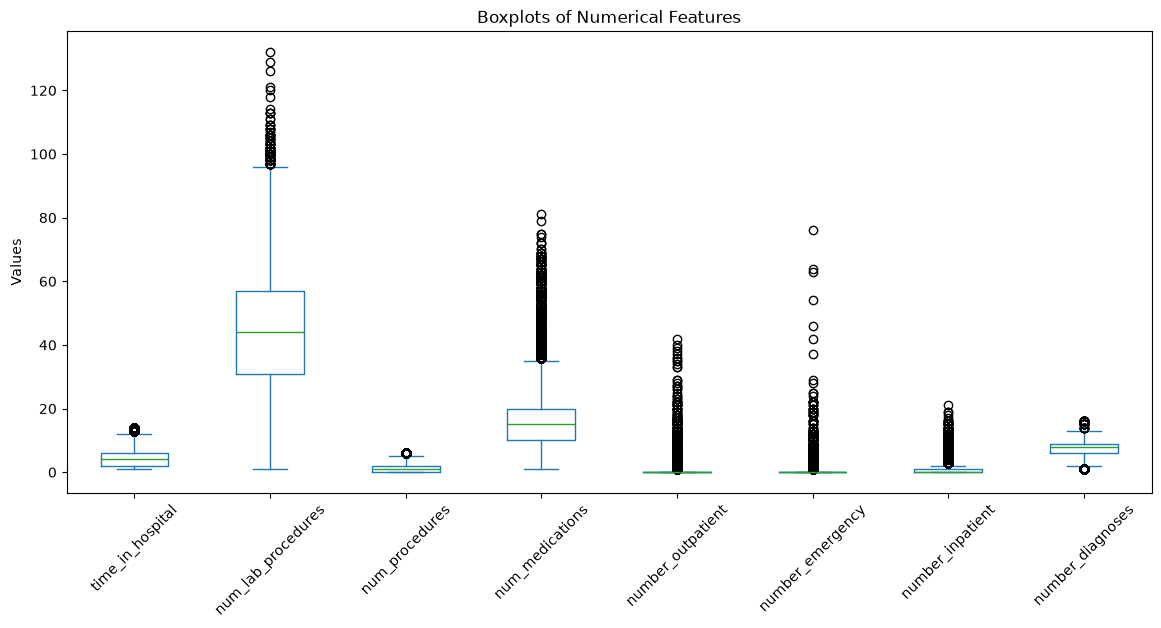

In [24]:
import matplotlib.pyplot as plt

df[numeric_features].plot(
    kind="box",
    figsize=(14, 6),
    rot=45
)

plt.title("Boxplots of Numerical Features")
plt.ylabel("Values")
plt.show()

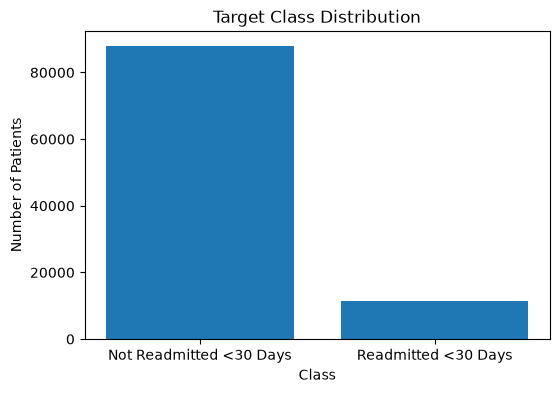

In [25]:
import matplotlib.pyplot as plt

target_counts = df["target"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(["Not Readmitted <30 Days", "Readmitted <30 Days"], target_counts.values)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

plt.show()

In [26]:
print("Target Distribution:")
print(df["target"].value_counts())

print("\nTarget Percentage:")
print((df["target"].value_counts(normalize=True) * 100).round(2))

Target Distribution:
target
0    88029
1    11314
Name: count, dtype: int64

Target Percentage:
target
0    88.61
1    11.39
Name: proportion, dtype: float64


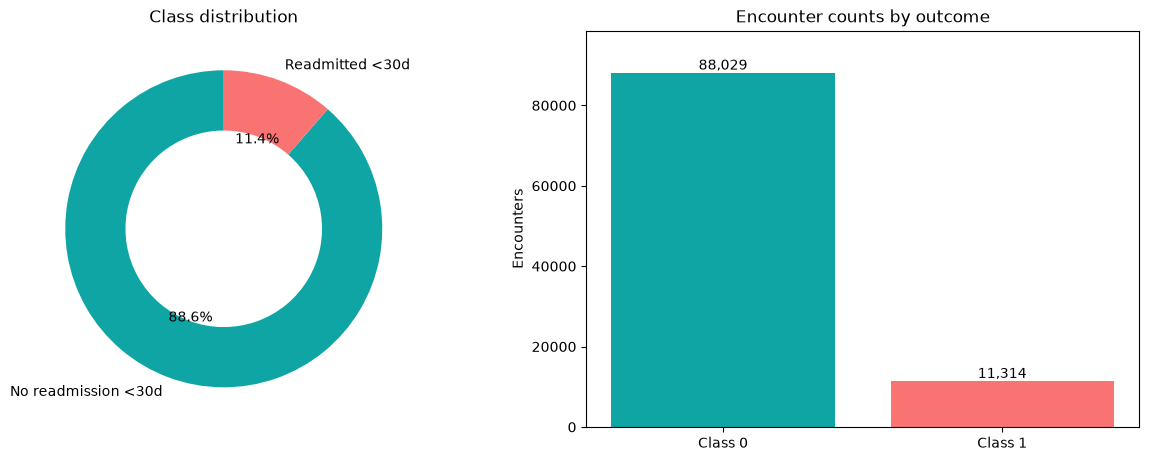

In [27]:
# Companion figures: target prevalence and counts, using the current cohort.
import matplotlib.pyplot as plt
counts=df["target"].value_counts().reindex([0,1],fill_value=0)
fig,axes=plt.subplots(1,2,figsize=(12,4.5),layout="constrained")
colors=["#0ea5a4","#f97373"]
axes[0].pie(counts,labels=["No readmission <30d","Readmitted <30d"],autopct="%1.1f%%",startangle=90,colors=colors,wedgeprops={"width":.38})
axes[0].set_title("Class distribution")
axes[1].bar(["Class 0","Class 1"],counts,color=colors)
for i,value in enumerate(counts): axes[1].text(i,value+max(counts)*.01,f"{value:,}",ha="center")
axes[1].set_ylim(0,max(counts)*1.12)
axes[1].set_ylabel("Encounters")
axes[1].set_title("Encounter counts by outcome")
plt.show()

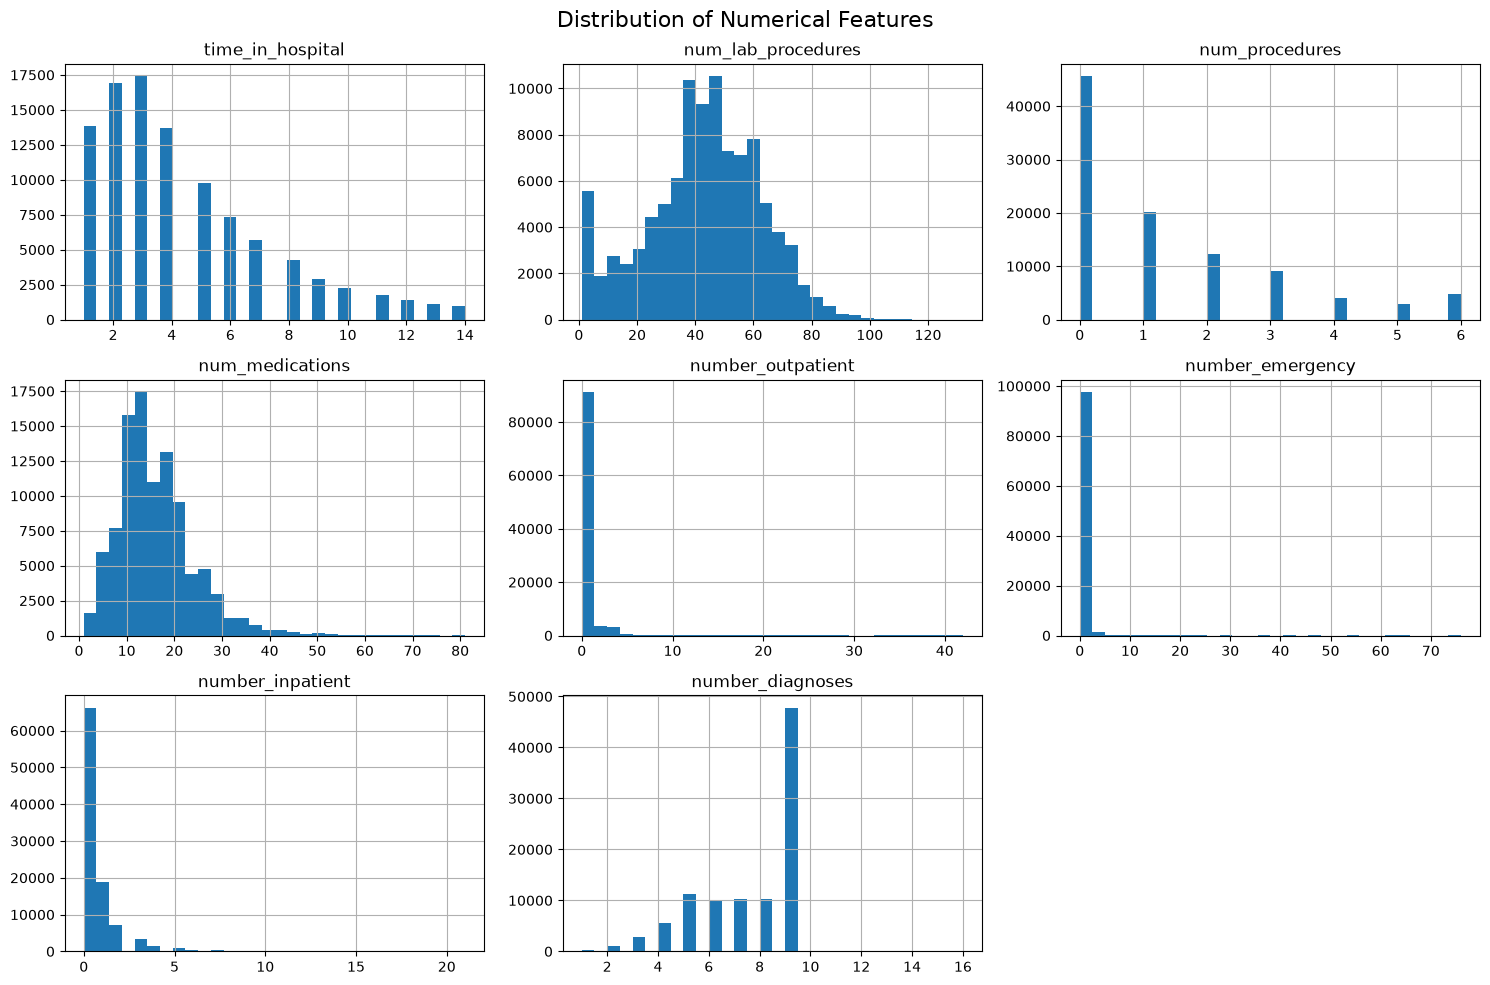

In [28]:
df[numeric_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

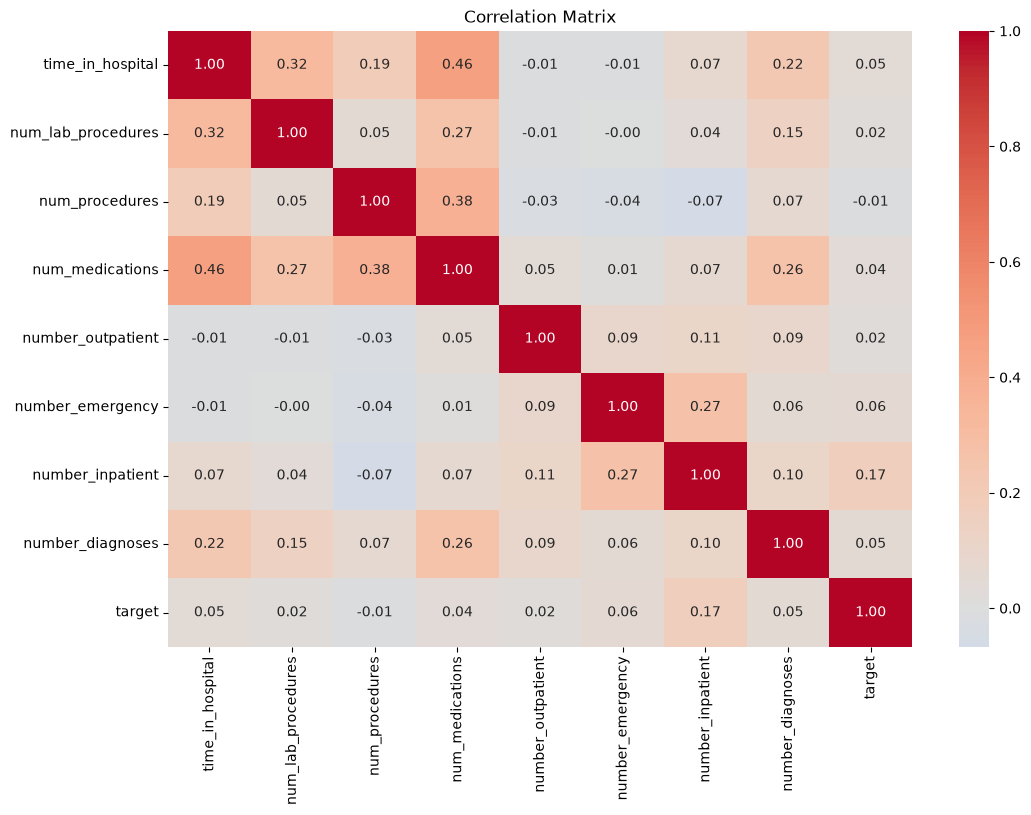

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_cols = numeric_features + ["target"]

corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

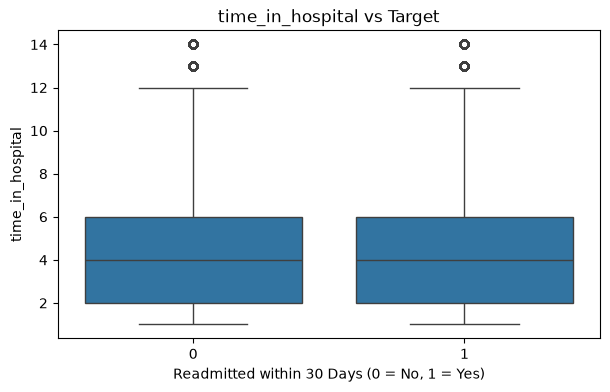

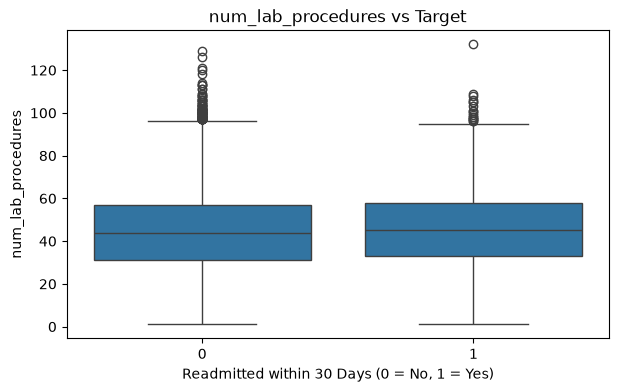

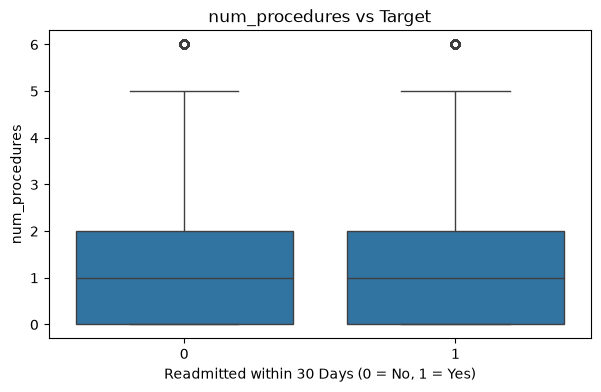

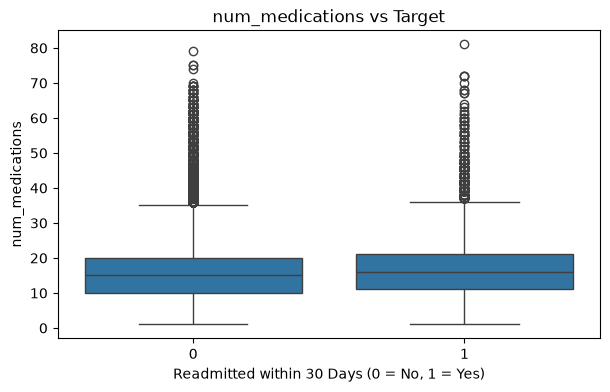

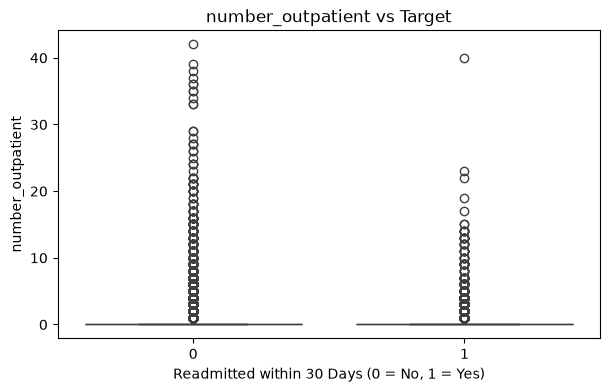

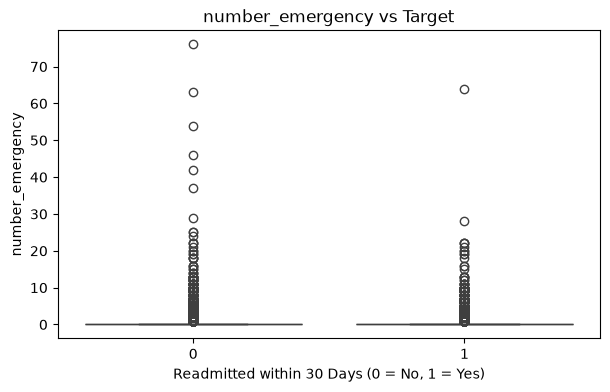

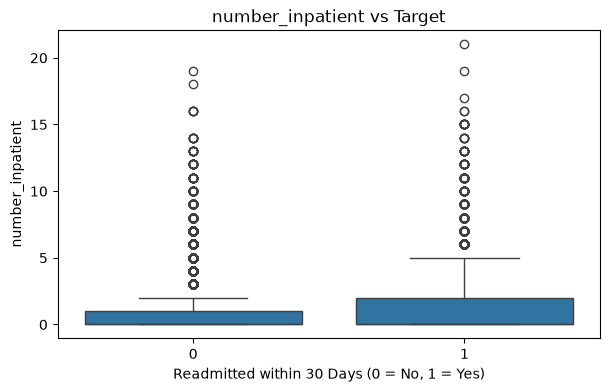

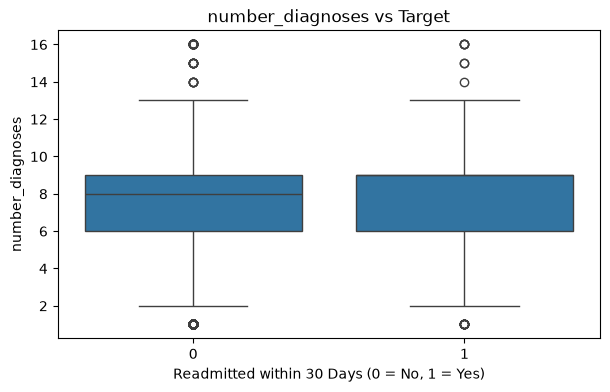

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        x="target",
        y=col,
        data=df
    )

    plt.title(f"{col} vs Target")
    plt.xlabel("Readmitted within 30 Days (0 = No, 1 = Yes)")
    plt.ylabel(col)
    plt.show()

In [31]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Number of categorical columns:", len(categorical_cols))
print("\nCategorical columns:")
print(list(categorical_cols))

Number of categorical columns: 34

Categorical columns:
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [32]:
categorical_eda = ["gender", "age", "diabetesMed", "change"]

for col in categorical_eda:
    print(f"\n{'='*50}")
    print(f"{col} vs Target")

    table = pd.crosstab(
        df[col],
        df["target"],
        normalize="index"
    ) * 100

    print(table.round(2))


gender vs Target
target        0      1
gender                
Female    88.54  11.46
Male      88.70  11.30
Unknown  100.00   0.00

age vs Target
target        0      1
age                   
[0-10)    98.12   1.88
[10-20)   94.20   5.80
[20-30)   85.69  14.31
[30-40)   88.74  11.26
[40-50)   89.34  10.66
[50-60)   90.23   9.77
[60-70)   88.70  11.30
[70-80)   87.94  12.06
[80-90)   87.43  12.57
[90-100)  88.10  11.90

diabetesMed vs Target
target           0      1
diabetesMed              
No           90.13   9.87
Yes          88.16  11.84

change vs Target
target      0      1
change              
Ch      87.98  12.02
No      89.16  10.84


In [33]:
from scipy.stats import chi2_contingency
import pandas as pd

chi2_results = []

categorical_features = [
    col for col in categorical_cols
    if col != "readmitted"
]

for col in categorical_features:
    contingency_table = pd.crosstab(df[col], df["target"])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    chi2_results.append({
        "Feature": col,
        "Chi2": chi2,
        "P_Value": p_value
    })

chi2_df = pd.DataFrame(chi2_results)

chi2_df = chi2_df.sort_values(
    by="P_Value",
    ascending=True
).reset_index(drop=True)

chi2_df

,Feature,Chi2,P_Value
0,diag_1,1836.719227,1.071464e-99
1,diag_3,1630.149297,2.953011e-61
2,diag_2,1434.450042,8.072815e-46
3,insulin,199.299886,5.976353e-43
4,medical_specialty,373.014980,3.552828e-42
5,age,133.599255,2.154572e-24
6,diabetesMed,66.766468,3.056533e-16
7,metformin,69.924727,4.429724e-15
8,payer_code,106.241098,6.122479e-15
9,A1Cresult,42.557541,3.055224e-09


In [34]:
from scipy.stats import f_oneway
import pandas as pd

anova_results = []

for col in numeric_features:
    group_0 = df[df["target"] == 0][col]
    group_1 = df[df["target"] == 1][col]

    f_stat, p_value = f_oneway(group_0, group_1)

    anova_results.append({
        "Feature": col,
        "F_Statistic": f_stat,
        "P_Value": p_value
    })

anova_df = pd.DataFrame(anova_results)

anova_df = anova_df.sort_values(
    by="P_Value",
    ascending=True
).reset_index(drop=True)

anova_df

,Feature,F_Statistic,P_Value
0,number_inpatient,2896.785697,0.000000e+00
1,number_emergency,369.624904,3.188749e-82
2,number_diagnoses,286.006739,4.534470e-64
3,time_in_hospital,218.862044,1.808657e-49
4,num_medications,168.743192,1.496665e-38
5,num_lab_procedures,57.463488,3.472836e-14
6,number_outpatient,36.516869,1.518869e-09
7,num_procedures,11.675661,6.334840e-04


## 5. Data Preprocessing
Treat admission/discharge IDs as categories. Exclude `encounter_id` and reserve `patient_nbr` strictly for patient-group splitting. Fit OneHotEncoder and StandardScaler on Train only, and transform Validation/Test with those fitted objects. The original notebook uses group separation across all three sets.

In [35]:
id_categorical_features = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

for col in id_categorical_features:
    df[col] = df[col].astype(str)

print(df[id_categorical_features].dtypes)

admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
dtype: object


### Patient-level Train / Validation / Test split
`GroupShuffleSplit` keeps all encounters from one `patient_nbr` in exactly one set. `encounter_id` is not used as a predictor. Fit preprocessing only on Train; use Validation for threshold decisions and Test for final reported metrics.

In [36]:
print(df.columns.tolist())

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'target']


In [37]:
target = "target"

# patient_nbr is used only for grouping; encounter_id is an identifier, not a clinical feature.
X = df.drop(columns=[target, "patient_nbr", "readmitted", "encounter_id"])
y = df[target]

groups = df.loc[X.index, "patient_nbr"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("encounter_id used as feature:", "encounter_id" in X.columns)


X shape: (99343, 44)
y shape: (99343,)
groups shape: (99343,)
encounter_id used as feature: False


In [38]:
from sklearn.model_selection import GroupShuffleSplit

groups = df.loc[X.index, "patient_nbr"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_group = X.iloc[train_idx].copy()
X_test_group = X.iloc[test_idx].copy()

y_train_group = y.iloc[train_idx].copy()
y_test_group = y.iloc[test_idx].copy()

print("X_train:", X_train_group.shape)
print("X_test :", X_test_group.shape)
print("y_train:", y_train_group.shape)
print("y_test :", y_test_group.shape)

X_train: (79541, 44)
X_test : (19802, 44)
y_train: (79541,)
y_test : (19802,)


In [39]:
train_patient_ids_group = set(
    df.loc[X_train_group.index, "patient_nbr"]
)

test_patient_ids_group = set(
    df.loc[X_test_group.index, "patient_nbr"]
)

overlap_group = train_patient_ids_group.intersection(
    test_patient_ids_group
)

print("Unique patients in Train:", len(train_patient_ids_group))
print("Unique patients in Test :", len(test_patient_ids_group))
print("Patients appearing in both:", len(overlap_group))

Unique patients in Train: 55992
Unique patients in Test : 13998
Patients appearing in both: 0


### Patient-level validation split
Split the training patients a second time to create Validation. The overlap checks in the next cell confirm that no patient appears in two sets. This gives a separate set for threshold selection without using the Test labels.

In [40]:
groups_train = df.loc[X_train_group.index, "patient_nbr"]

gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx2, val_idx2 = next(
    gss_val.split(X_train_group, y_train_group, groups=groups_train)
)

X_val_group = X_train_group.iloc[val_idx2].copy()
y_val_group = y_train_group.iloc[val_idx2].copy()

X_train_group = X_train_group.iloc[train_idx2].copy()
y_train_group = y_train_group.iloc[train_idx2].copy()

print("X_train:", X_train_group.shape)
print("X_val  :", X_val_group.shape)
print("X_test :", X_test_group.shape)

# Confirm there is still no patient overlap between any of the three sets
train_ids2 = set(df.loc[X_train_group.index, "patient_nbr"])
val_ids2 = set(df.loc[X_val_group.index, "patient_nbr"])
test_ids2 = set(df.loc[X_test_group.index, "patient_nbr"])

print("Train/Val overlap :", len(train_ids2 & val_ids2))
print("Train/Test overlap:", len(train_ids2 & test_ids2))
print("Val/Test overlap  :", len(val_ids2 & test_ids2))


X_train: (63807, 44)
X_val  : (15734, 44)
X_test : (19802, 44)
Train/Val overlap : 0
Train/Test overlap: 0
Val/Test overlap  : 0


## 6. Feature Engineering
Map ICD diagnosis codes into broader groups using the same fixed mapping for Train, Validation and Test. Numerical stay/utilization values and categorical hospital/medication values then enter encoding and scaling. PCA is optional under the project rubric and is not applied to this sparse, one-hot representation.

In [41]:
# Numerical features
numeric_features_group = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

# Categorical features
categorical_features_group = [
    col for col in X_train_group.columns
    if col not in numeric_features_group
]

print("Number of numerical features:", len(numeric_features_group))
print("Number of categorical features:", len(categorical_features_group))

print("\nNumerical features:")
print(numeric_features_group)

print("\nCategorical features:")
print(categorical_features_group)

Number of numerical features: 8
Number of categorical features: 36

Numerical features:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical features:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [42]:
def map_diagnosis(code):
    code = str(code)

    # V-codes
    if code.startswith("V"):
        return "Supplementary"

    # E-codes
    if code.startswith("E"):
        return "External_Cause"

    try:
        code_num = float(code)
    except:
        return "Unknown"

    if 390 <= code_num <= 459 or code_num == 785:
        return "Circulatory"

    elif 460 <= code_num <= 519 or code_num == 786:
        return "Respiratory"

    elif 520 <= code_num <= 579 or code_num == 787:
        return "Digestive"

    elif 250 <= code_num < 251:
        return "Diabetes"

    elif 800 <= code_num <= 999:
        return "Injury_Poisoning"

    elif 710 <= code_num <= 739:
        return "Musculoskeletal"

    elif 580 <= code_num <= 629:
        return "Genitourinary"

    elif 630 <= code_num <= 679:
        return "Pregnancy"

    elif 140 <= code_num <= 239:
        return "Neoplasms"

    elif 280 <= code_num <= 289:
        return "Blood"

    elif 290 <= code_num <= 319:
        return "Mental"

    elif 320 <= code_num <= 359:
        return "Nervous"

    elif 360 <= code_num <= 389:
        return "Sense_Organs"

    elif 680 <= code_num <= 709:
        return "Skin"

    elif 240 <= code_num <= 249:
        return "Endocrine"

    else:
        return "Other"


for col in ["diag_1", "diag_2", "diag_3"]:
    X_train_group[col] = X_train_group[col].apply(map_diagnosis)
    X_val_group[col] = X_val_group[col].apply(map_diagnosis)
    X_test_group[col] = X_test_group[col].apply(map_diagnosis)

print("Diagnosis grouping completed.")

print("\nTrain diagnosis groups:")
print(X_train_group["diag_1"].value_counts().head(20))

Diagnosis grouping completed.

Train diagnosis groups:
diag_1
Circulatory         19075
Respiratory          9037
Digestive            6034
Diabetes             5486
Other                5362
Injury_Poisoning     4387
Genitourinary        3196
Musculoskeletal      3165
Neoplasms            2025
Skin                 1585
Mental               1463
Supplementary        1017
Blood                 694
Nervous               610
Pregnancy             420
Sense_Organs          169
Endocrine              68
Unknown                13
External_Cause          1
Name: count, dtype: int64


In [43]:
from sklearn.preprocessing import OneHotEncoder

encoder_group = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# Fit ONLY on training data
encoder_group.fit(
    X_train_group[categorical_features_group]
)

# Transform train, validation and test
X_train_encoded_group = encoder_group.transform(
    X_train_group[categorical_features_group]
)

X_val_encoded_group = encoder_group.transform(
    X_val_group[categorical_features_group]
)

X_test_encoded_group = encoder_group.transform(
    X_test_group[categorical_features_group]
)

print("Train encoded shape:", X_train_encoded_group.shape)
print("Val encoded shape  :", X_val_encoded_group.shape)
print("Test encoded shape :", X_test_encoded_group.shape)


Train encoded shape: (63807, 286)
Val encoded shape  : (15734, 286)
Test encoded shape : (19802, 286)


In [44]:
from sklearn.preprocessing import StandardScaler

scaler_group = StandardScaler()

# Fit ONLY on training data
X_train_num_group = scaler_group.fit_transform(
    X_train_group[numeric_features_group]
)

# Transform validation and test data
X_val_num_group = scaler_group.transform(
    X_val_group[numeric_features_group]
)

X_test_num_group = scaler_group.transform(
    X_test_group[numeric_features_group]
)

print("Train numerical shape:", X_train_num_group.shape)
print("Val numerical shape  :", X_val_num_group.shape)
print("Test numerical shape :", X_test_num_group.shape)


Train numerical shape: (63807, 8)
Val numerical shape  : (15734, 8)
Test numerical shape : (19802, 8)


In [45]:
from scipy.sparse import hstack, csr_matrix

X_train_processed_group = hstack([
    X_train_encoded_group,
    csr_matrix(X_train_num_group)
]).tocsr()

X_val_processed_group = hstack([
    X_val_encoded_group,
    csr_matrix(X_val_num_group)
]).tocsr()

X_test_processed_group = hstack([
    X_test_encoded_group,
    csr_matrix(X_test_num_group)
]).tocsr()

print("Final Train shape:", X_train_processed_group.shape)
print("Final Val shape  :", X_val_processed_group.shape)
print("Final Test shape :", X_test_processed_group.shape)


Final Train shape: (63807, 294)
Final Val shape  : (15734, 294)
Final Test shape : (19802, 294)


In [46]:
print("Training target distribution:")
print(y_train_group.value_counts())

print("\nTraining target percentage:")
print(y_train_group.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
print(y_val_group.value_counts())

print("\nValidation target percentage:")
print(y_val_group.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test_group.value_counts())

print("\nTest target percentage:")
print(y_test_group.value_counts(normalize=True) * 100)


Training target distribution:
target
0    56511
1     7296
Name: count, dtype: int64

Training target percentage:
target
0    88.565518
1    11.434482
Name: proportion, dtype: float64

Validation target distribution:
target
0    13932
1     1802
Name: count, dtype: int64

Validation target percentage:
target
0    88.547095
1    11.452905
Name: proportion, dtype: float64

Test target distribution:
target
0    17586
1     2216
Name: count, dtype: int64

Test target percentage:
target
0    88.809211
1    11.190789
Name: proportion, dtype: float64


### Training-only feature selection review
The diagnosis categories are newly engineered features. Fit a small tree ensemble on Train only to rank the encoded features and display a candidate short list. The original three models continue using their existing full feature set, so this diagnostic does not overwrite recorded results. PCA is optional and not needed to satisfy the rubric.

In [47]:
from sklearn.ensemble import ExtraTreesClassifier
selector_review = ExtraTreesClassifier(n_estimators=80, min_samples_leaf=10, random_state=42, n_jobs=-1)
selector_review.fit(X_train_processed_group, y_train_group)
feature_labels = list(encoder_group.get_feature_names_out(categorical_features_group)) + list(numeric_features_group)
feature_ranking = pd.Series(selector_review.feature_importances_, index=feature_labels).sort_values(ascending=False)
selected_feature_names = feature_ranking.head(20).index.tolist()
display(feature_ranking.head(20).rename("Train-only feature importance").to_frame())
print("Candidate selected features:", selected_feature_names)

,Train-only feature importance
number_inpatient,0.093654
discharge_disposition_id_22,0.038642
discharge_disposition_id_1,0.036662
time_in_hospital,0.018751
medical_specialty_Unknown,0.016877
number_diagnoses,0.016700
gender_Male,0.016185
payer_code_Unknown,0.016017
discharge_disposition_id_3,0.015689
diag_1_Circulatory,0.015307


Candidate selected features: ['number_inpatient', 'discharge_disposition_id_22', 'discharge_disposition_id_1', 'time_in_hospital', 'medical_specialty_Unknown', 'number_diagnoses', 'gender_Male', 'payer_code_Unknown', 'discharge_disposition_id_3', 'diag_1_Circulatory', 'diag_2_Circulatory', 'gender_Female', 'payer_code_MC', 'age_[70-80)', 'num_procedures', 'diag_3_Circulatory', 'num_medications', 'admission_type_id_1', 'admission_source_id_7', 'num_lab_procedures']


## 7. Model Building
The original results below train Logistic Regression, Random Forest and XGBoost, fulfilling the official minimum of three algorithms. All models share the original patient-separated data and use Validation for thresholds. Recorded numerical results are preserved verbatim.

### 7.1 Logistic Regression baseline
Train with balanced class weights. Select its classification threshold by class-1 F1 on Validation, and report both discrimination and threshold-dependent metrics.

In [48]:
from sklearn.linear_model import LogisticRegression

logistic_group = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

logistic_group.fit(
    X_train_processed_group,
    y_train_group
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


## 8. Model Evaluation
The original notebook evaluates Logistic Regression, Random Forest and XGBoost, then compares Accuracy, Precision, Recall, F1, ROC-AUC and PR-AUC. The existing cells calculate final results for each of the three models on Test. Use the added Validation comparison for model choice; do not claim that the original notebook only used Test once.

#### Threshold tuning on Validation only

In [49]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_prob_logistic_group_val = logistic_group.predict_proba(X_val_processed_group)[:, 1]
y_prob_logistic_group_test = logistic_group.predict_proba(X_test_processed_group)[:, 1]

thresholds_lr_group = np.arange(0.10, 0.51, 0.05)
results_lr_group_threshold = []

for threshold in thresholds_lr_group:
    y_pred_threshold = (y_prob_logistic_group_val >= threshold).astype(int)
    results_lr_group_threshold.append({
        "Threshold": round(float(threshold), 2),
        "Accuracy": accuracy_score(y_val_group, y_pred_threshold),
        "Precision": precision_score(y_val_group, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_val_group, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_val_group, y_pred_threshold, zero_division=0)
    })

results_lr_group_threshold_df = pd.DataFrame(results_lr_group_threshold)
best_row_lr_group = results_lr_group_threshold_df.loc[results_lr_group_threshold_df["F1"].idxmax()]
best_threshold_lr_group = float(best_row_lr_group["Threshold"])

print("Best Logistic Regression threshold chosen on VALIDATION:")
print(best_row_lr_group)


Best Logistic Regression threshold chosen on VALIDATION:
Threshold    0.500000
Accuracy     0.669061
Precision    0.183844
Recall       0.549390
F1           0.275497
Name: 8, dtype: float64


In [50]:
from sklearn.metrics import average_precision_score

y_pred_logistic_group_final = (y_prob_logistic_group_test >= best_threshold_lr_group).astype(int)

logistic_group_final_metrics = {
    "Model": "Logistic Regression",
    "Threshold": best_threshold_lr_group,
    "Accuracy": accuracy_score(y_test_group, y_pred_logistic_group_final),
    "Precision": precision_score(y_test_group, y_pred_logistic_group_final, zero_division=0),
    "Recall": recall_score(y_test_group, y_pred_logistic_group_final, zero_division=0),
    "F1": f1_score(y_test_group, y_pred_logistic_group_final, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_group, y_prob_logistic_group_test),
    "PR-AUC": average_precision_score(y_test_group, y_prob_logistic_group_test)
}

print("Logistic Regression — FINAL TEST results")
for k, v in logistic_group_final_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")


Logistic Regression — FINAL TEST results
Model: Logistic Regression
Threshold: 0.5000
Accuracy: 0.6659
Precision: 0.1791
Recall: 0.5542
F1: 0.2707
ROC-AUC: 0.6649
PR-AUC: 0.2194


### Logistic Regression results
The table below shows the original recorded held-out baseline. Interpret class-1 F1 and PR-AUC alongside accuracy because the positive class is uncommon.

In [51]:
# Fixed baseline results — use this schema for every next model
baseline_results = pd.DataFrame([logistic_group_final_metrics])
baseline_results = baseline_results[["Model", "Threshold", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
display(baseline_results.style.format({
    "Threshold": "{:.2f}",
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}))


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.50,0.6659,0.1791,0.5542,0.2707,0.6649


In [52]:
print("Target distribution:")
print(y.value_counts())

print("\nX columns:")
print(X.columns.tolist())

Target distribution:
target
0    88029
1    11314
Name: count, dtype: int64

X columns:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


RandomForestClassifier
-------------------

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_group = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_group.fit(
    X_train_processed_group,
    y_train_group
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [54]:
y_prob_rf_val = rf_group.predict_proba(
    X_val_processed_group
)[:, 1]

print("Validation probabilities generated successfully.")

Validation probabilities generated successfully.


In [55]:
thresholds_rf_group = np.arange(0.10, 0.51, 0.05)

rf_threshold_results = []

for threshold in thresholds_rf_group:
    y_pred = (y_prob_rf_val >= threshold).astype(int)

    rf_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val_group, y_pred),
        "Precision": precision_score(y_val_group, y_pred, zero_division=0),
        "Recall": recall_score(y_val_group, y_pred, zero_division=0),
        "F1": f1_score(y_val_group, y_pred, zero_division=0)
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)

rf_threshold_df.sort_values(
    "F1",
    ascending=False
).head(10)

,Threshold,Accuracy,Precision,Recall,F1
3,0.25,0.684441,0.188129,0.529412,0.277608
4,0.30,0.781810,0.217722,0.349057,0.268173
2,0.20,0.530317,0.159102,0.723640,0.260852
1,0.15,0.357506,0.137597,0.875139,0.237804
5,0.35,0.839202,0.255705,0.211432,0.231470
0,0.10,0.191687,0.120867,0.965594,0.214841
6,0.40,0.868501,0.304539,0.115427,0.167404
7,0.45,0.878734,0.330128,0.057159,0.097446
8,0.50,0.882420,0.320896,0.023862,0.044421


In [56]:
# Select the Random Forest threshold from validation F1 (never from the test set).
best_rf_row = rf_threshold_df.loc[rf_threshold_df["F1"].idxmax()]
best_rf_threshold = float(best_rf_row["Threshold"])

print("Best Random Forest threshold chosen on VALIDATION:")
print(best_rf_row)


Best Random Forest threshold chosen on VALIDATION:
Threshold    0.250000
Accuracy     0.684441
Precision    0.188129
Recall       0.529412
F1           0.277608
Name: 3, dtype: float64


In [57]:
# Final Random Forest evaluation on the untouched test set

y_prob_rf_test = rf_group.predict_proba(
    X_test_processed_group
)[:, 1]

y_pred_rf_test = (
    y_prob_rf_test >= best_rf_threshold
).astype(int)

rf_test_results = {
    "Model": "Random Forest",
    "Threshold": best_rf_threshold,
    "Accuracy": accuracy_score(y_test_group, y_pred_rf_test),
    "Precision": precision_score(y_test_group, y_pred_rf_test, zero_division=0),
    "Recall": recall_score(y_test_group, y_pred_rf_test, zero_division=0),
    "F1": f1_score(y_test_group, y_pred_rf_test, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_group, y_prob_rf_test),
    "PR-AUC": average_precision_score(y_test_group, y_prob_rf_test)
}

pd.DataFrame([rf_test_results])

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.25,0.679628,0.18207,0.533394,0.271475,0.6647,0.220324


XGBClassifier
--------------------

In [58]:
from xgboost import XGBClassifier

xgb_group = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_group.fit(
    X_train_processed_group,
    y_train_group
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [59]:
# Generate validation probabilities for XGBoost

y_prob_xgb_val = xgb_group.predict_proba(
    X_val_processed_group
)[:, 1]

print("Validation probabilities generated successfully.")

Validation probabilities generated successfully.


In [60]:
# Evaluate XGBoost across different thresholds on validation set

thresholds = np.arange(0.10, 0.51, 0.05)

xgb_threshold_results = []

for threshold in thresholds:
    y_pred_xgb_val = (
        y_prob_xgb_val >= threshold
    ).astype(int)

    xgb_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val_group, y_pred_xgb_val),
        "Precision": precision_score(
            y_val_group, y_pred_xgb_val, zero_division=0
        ),
        "Recall": recall_score(
            y_val_group, y_pred_xgb_val, zero_division=0
        ),
        "F1": f1_score(
            y_val_group, y_pred_xgb_val, zero_division=0
        )
    })

xgb_threshold_df = pd.DataFrame(xgb_threshold_results)

xgb_threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.572963,0.168800,0.695339,0.271653
1,0.15,0.779776,0.231688,0.398446,0.293001
2,0.20,0.849371,0.292701,0.222531,0.252837
3,0.25,0.873332,0.351477,0.125416,0.184867
4,0.30,0.880196,0.389333,0.081021,0.134130
5,0.35,0.883374,0.426009,0.052719,0.093827
6,0.40,0.885280,0.487805,0.033296,0.062338
7,0.45,0.885662,0.523810,0.018313,0.035389
8,0.50,0.885725,0.558824,0.010544,0.020697


In [61]:
# Select the XGBoost threshold from validation F1 (never from the test set).
best_xgb_row = xgb_threshold_df.loc[xgb_threshold_df["F1"].idxmax()]
best_xgb_threshold = float(best_xgb_row["Threshold"])

print("Best XGBoost threshold chosen on VALIDATION:")
print(best_xgb_row)


Best XGBoost threshold chosen on VALIDATION:
Threshold    0.150000
Accuracy     0.779776
Precision    0.231688
Recall       0.398446
F1           0.293001
Name: 1, dtype: float64


In [62]:
# Final XGBoost evaluation on the untouched test set

y_prob_xgb_test = xgb_group.predict_proba(
    X_test_processed_group
)[:, 1]

y_pred_xgb_test = (
    y_prob_xgb_test >= best_xgb_threshold
).astype(int)

xgb_test_results = {
    "Model": "XGBoost",
    "Threshold": best_xgb_threshold,
    "Accuracy": accuracy_score(y_test_group, y_pred_xgb_test),
    "Precision": precision_score(
        y_test_group, y_pred_xgb_test, zero_division=0
    ),
    "Recall": recall_score(
        y_test_group, y_pred_xgb_test, zero_division=0
    ),
    "F1": f1_score(
        y_test_group, y_pred_xgb_test, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test_group, y_prob_xgb_test
    ),
    "PR-AUC": average_precision_score(
        y_test_group, y_prob_xgb_test
    )
}

pd.DataFrame([xgb_test_results])

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.15,0.776033,0.22311,0.40343,0.287321,0.674664,0.237953


In [63]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [64]:
# Validation-only comparison: read existing validation threshold tables, no test-based selection.
validation_comparison=pd.DataFrame([
 {"Model":"Logistic Regression",**results_lr_group_threshold_df.loc[results_lr_group_threshold_df["F1"].idxmax()].to_dict()},
 {"Model":"Random Forest",**rf_threshold_df.loc[rf_threshold_df["F1"].idxmax()].to_dict()},
 {"Model":"XGBoost",**xgb_threshold_df.loc[xgb_threshold_df["F1"].idxmax()].to_dict()}
]).sort_values("F1",ascending=False)
display(validation_comparison)
selected_name=str(validation_comparison.iloc[0]["Model"])
print("Validation-selected model:",selected_name)

,Model,Threshold,Accuracy,Precision,Recall,F1
2,XGBoost,0.15,0.779776,0.231688,0.398446,0.293001
1,Random Forest,0.25,0.684441,0.188129,0.529412,0.277608
0,Logistic Regression,0.50,0.669061,0.183844,0.549390,0.275497


Validation-selected model: XGBoost


### Final Model Comparison — Test Set

This cell combines the final test results for Logistic Regression, Random Forest, and XGBoost into one table. It shows each model’s selected threshold and evaluation metrics: Accuracy, Precision, Recall, F1-score, ROC-AUC, and PR-AUC.

Because the dataset is imbalanced, focus on **Precision, Recall, and F1-score for Class 1**, alongside PR-AUC, rather than choosing a model by Accuracy alone. The thresholds were selected on the Validation set; this table reports their performance on the Test set.

In [65]:
# Final comparison of all trained models — generated from the actual test results.
final_model_results = pd.DataFrame([
    logistic_group_final_metrics,
    rf_test_results,
    xgb_test_results
])

final_model_results = final_model_results[[
    "Model", "Threshold", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"
]]

final_model_results


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.50,0.665892,0.179113,0.554152,0.270723,0.664881,0.219353
1,Random Forest,0.25,0.679628,0.182070,0.533394,0.271475,0.664700,0.220324
2,XGBoost,0.15,0.776033,0.223110,0.403430,0.287321,0.674664,0.237953


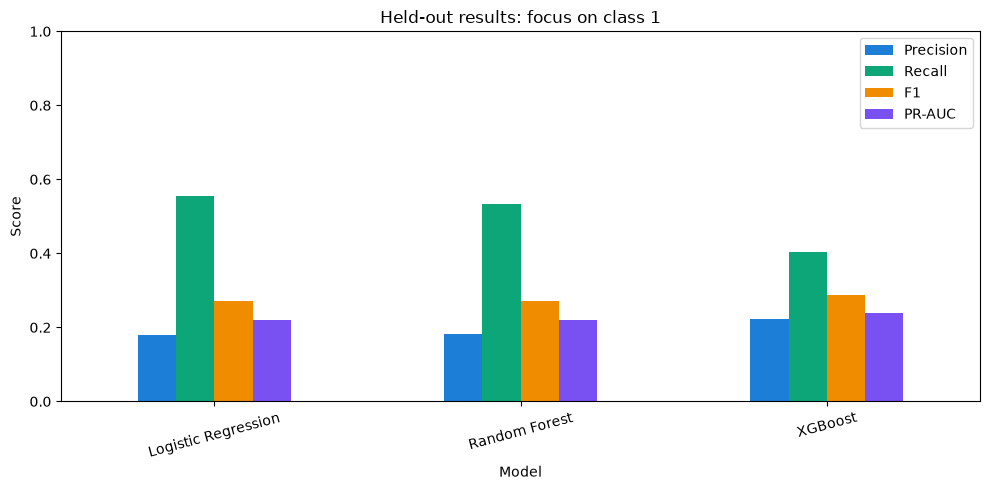

In [66]:
# Visual comparison of recorded test metrics; figures do not change predictions.
ax=final_model_results.set_index("Model")[["Precision","Recall","F1","PR-AUC"]].plot(kind="bar",figsize=(10,5),color=["#1c7ed6","#0ca678","#f08c00","#7950f2"])
ax.set_title("Held-out results: focus on class 1")
ax.set_ylabel("Score")
ax.set_ylim(0,1)
ax.tick_params(axis="x",rotation=15)
plt.tight_layout();plt.show()

In [67]:
print("Available test variables:")

for name in [
    "y_test_group",
    "y_test",
    "y_pred_xgb_test",
    "y_prob_xgb_test"
]:
    print(name, "exists" if name in globals() else "NOT FOUND")

Available test variables:
y_test_group exists
y_test NOT FOUND
y_pred_xgb_test exists
y_prob_xgb_test exists


### XGBoost Confusion Matrix — Test Set

This cell displays the confusion matrix for XGBoost on the Test set. The rows show the actual classes, and the columns show the predicted classes:

- **True Negative (TN):** Not readmitted and predicted as not readmitted.
- **False Positive (FP):** Not readmitted but predicted as readmitted.
- **False Negative (FN):** Readmitted within 30 days but predicted as not readmitted.
- **True Positive (TP):** Readmitted within 30 days and correctly predicted as readmitted.

Pay particular attention to **FN**, which represents missed readmissions, and **FP**, which represents false alerts. This matrix evaluates XGBoost specifically, not whichever model ranks first in the comparison table.

Confusion Matrix:
[[14473  3113]
 [ 1322   894]]


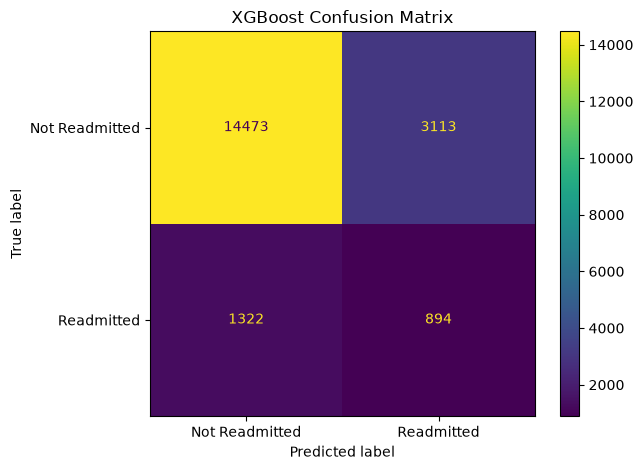

In [68]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_xgb = confusion_matrix(
    y_test_group,
    y_pred_xgb_test
)

print("Confusion Matrix:")
print(cm_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Not Readmitted", "Readmitted"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

### XGBoost ROC Curve — Test Set

This cell plots the **ROC curve** for XGBoost using its predicted probabilities on the Test set. It shows how the True Positive Rate (Recall) changes against the False Positive Rate across different classification thresholds.

The dashed diagonal represents a random classifier. A curve closer to the top-left corner and a higher **ROC-AUC** indicate better ability to distinguish the two classes.

Because readmission within 30 days is the minority class, interpret ROC-AUC alongside **PR-AUC, Class 1 Precision, Recall, and F1-score**.

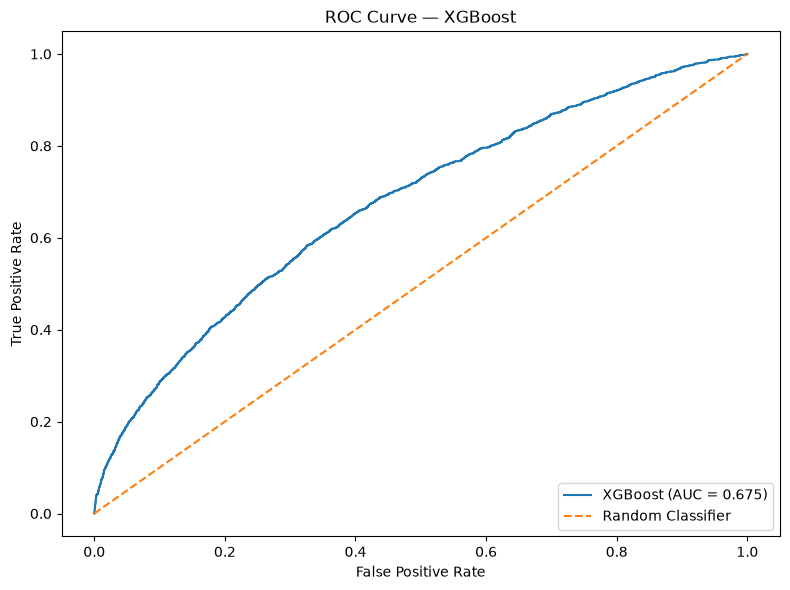

In [69]:
from sklearn.metrics import roc_curve, roc_auc_score

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test_group,
    y_prob_xgb_test
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_score(y_test_group, y_prob_xgb_test):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Diagnostic interpretation
The confusion matrix displayed below belongs specifically to XGBoost, as in the original notebook. Read its false negatives and false positives together with class-1 F1; its threshold was selected on Validation.

### Precision–Recall curve
Compare the curve with the class-1 prevalence baseline. The existing plot is for XGBoost and does not by itself establish which model should be deployed.

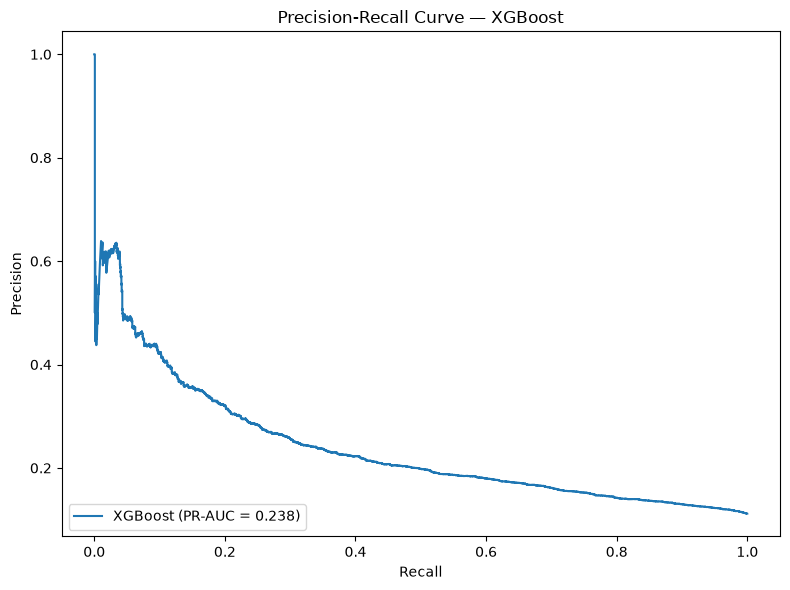

In [70]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test_group, y_prob_xgb_test)
pr_auc_xgb = average_precision_score(y_test_group, y_prob_xgb_test)

plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, label=f"XGBoost (PR-AUC = {pr_auc_xgb:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


### Feature importance and SHAP-style explanation (XGBoost)
The original model and results are unchanged. The following figures calculate TreeSHAP contributions from XGBoost for a small Validation sample and display mean absolute contribution plus a summary scatter. These are associations in the model, not causal medical effects.

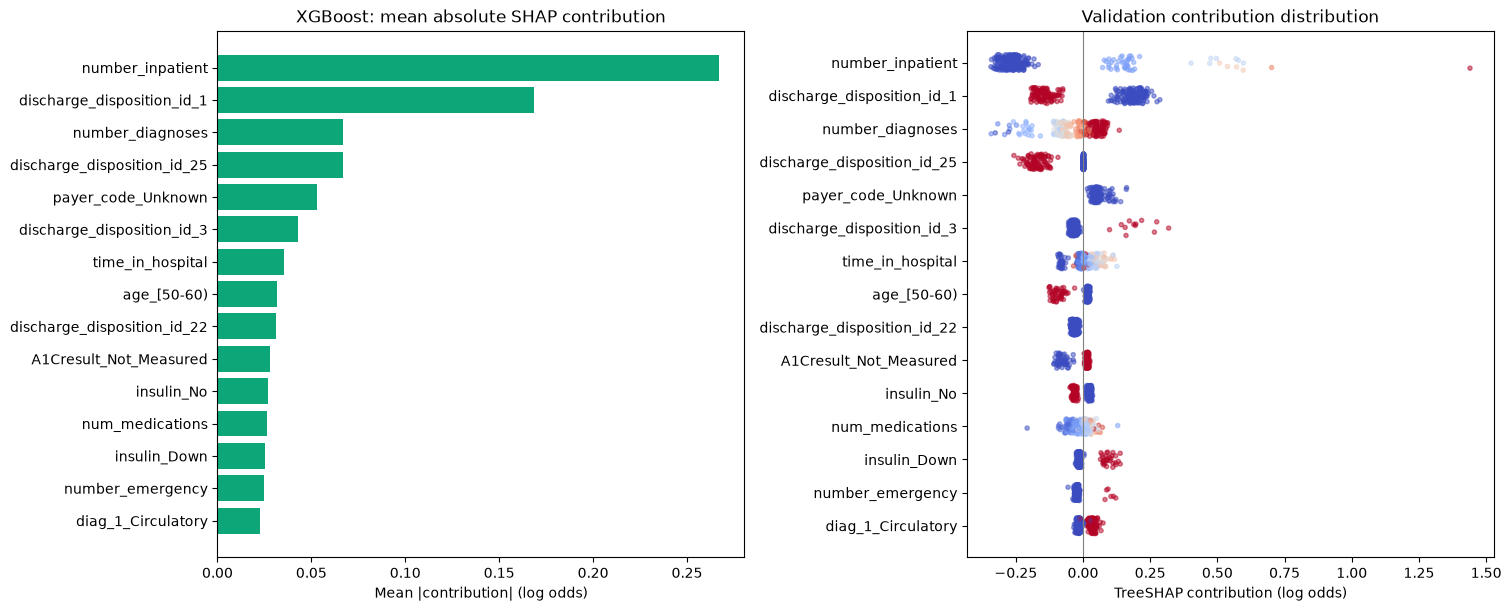

In [71]:
# XGBoost TreeSHAP values for a small, reproducible Validation sample.
from xgboost import DMatrix
from scipy import sparse
sample_size=min(250,X_val_processed_group.shape[0])
sample_matrix=X_val_processed_group[:sample_size]
feature_names=list(encoder_group.get_feature_names_out(categorical_features_group))+list(numeric_features_group)
contrib=xgb_group.get_booster().predict(DMatrix(sample_matrix),pred_contribs=True)[:,:-1]
rank=np.argsort(np.abs(contrib).mean(axis=0))[-15:][::-1]
fig,axes=plt.subplots(1,2,figsize=(15,6),layout='constrained')
axes[0].barh(np.arange(len(rank)),np.abs(contrib[:,rank]).mean(axis=0)[::-1],color='#0ca678')
axes[0].set_yticks(np.arange(len(rank)),[feature_names[j] for j in rank[::-1]])
axes[0].set_title('XGBoost: mean absolute SHAP contribution')
axes[0].set_xlabel('Mean |contribution| (log odds)')
values=sample_matrix[:,rank].toarray() if sparse.issparse(sample_matrix) else sample_matrix[:,rank]
for k,j in enumerate(rank[::-1]):
    original_pos=list(rank).index(j)
    axes[1].scatter(contrib[:,j],np.full(sample_size,k)+np.random.default_rng(k).uniform(-.24,.24,sample_size),c=values[:,original_pos],cmap='coolwarm',s=9,alpha=.5)
axes[1].set_yticks(np.arange(len(rank)),[feature_names[j] for j in rank[::-1]])
axes[1].axvline(0,color='gray',linewidth=.8)
axes[1].set_xlabel('TreeSHAP contribution (log odds)')
axes[1].set_title('Validation contribution distribution')
plt.show()

## 9. Model Optimization
The original notebook optimizes each model's decision threshold by Validation F1. The following charts visualize that choice using Validation data only. They do not update the original test predictions. Hyperparameter search is a separate optional experiment; its effect must be checked with a fresh, untouched test set before claiming an improvement.

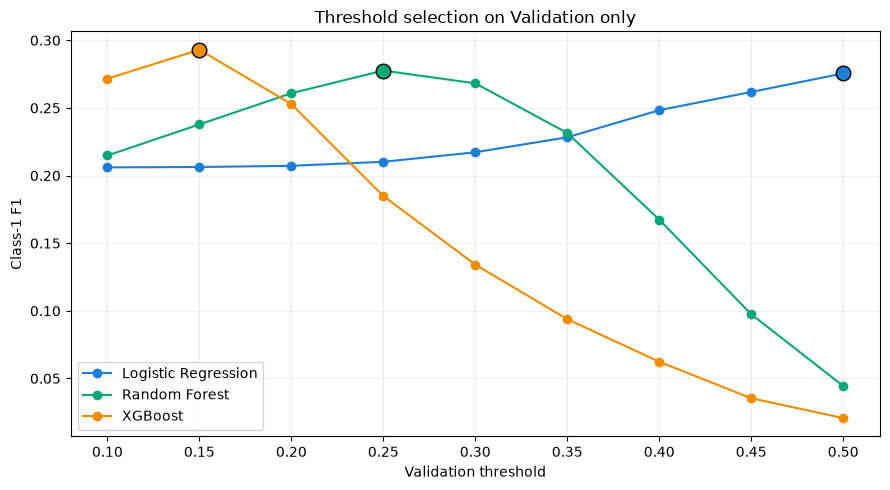

In [72]:
# Threshold sensitivity: validation F1 versus threshold for the original three models.
fig,ax=plt.subplots(figsize=(9,5))
for name,frame,color in [("Logistic Regression",results_lr_group_threshold_df,"#1c7ed6"),("Random Forest",rf_threshold_df,"#0ca678"),("XGBoost",xgb_threshold_df,"#f08c00")]:
    ax.plot(frame["Threshold"],frame["F1"],marker="o",label=name,color=color)
    ix=frame["F1"].idxmax()
    ax.scatter(frame.loc[ix,"Threshold"],frame.loc[ix,"F1"],s=110,edgecolor="black",color=color,zorder=3)
ax.set(xlabel="Validation threshold",ylabel="Class-1 F1",title="Threshold selection on Validation only")
ax.legend();ax.grid(alpha=.2);plt.tight_layout();plt.show()

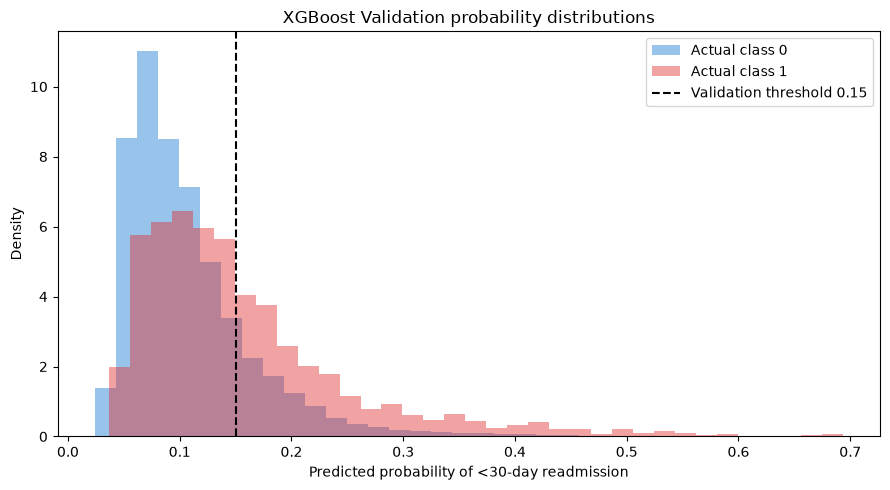

In [73]:
# Probability separation on Validation for XGBoost; illustrative distribution, not a test-set tuning step.
fig,ax=plt.subplots(figsize=(9,5))
for cls,color,label in [(0,"#1c7ed6","Actual class 0"),(1,"#e03131","Actual class 1")]:
    ax.hist(y_prob_xgb_val[y_val_group.to_numpy()==cls],bins=35,density=True,alpha=.45,color=color,label=label)
ax.axvline(best_xgb_threshold,color="black",linestyle="--",label=f"Validation threshold {best_xgb_threshold:.2f}")
ax.set(xlabel="Predicted probability of <30-day readmission",ylabel="Density",title="XGBoost Validation probability distributions")
ax.legend();plt.tight_layout();plt.show()

### Optional grouped hyperparameter search
This small Random Forest search performs grouped cross-validation on Train and checks its result on Validation. It is a documented optimization experiment, not an automatic replacement for the earlier fitted models or the previously reported Test results. A change to the final model would require a new, clean final evaluation.

In [74]:
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
search_groups = df.loc[X_train_group.index, "patient_nbr"]
rf_search = RandomizedSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"),
    {"max_depth": [8, 14, None], "min_samples_leaf": [2, 8, 20]},
    n_iter=3, scoring="average_precision", cv=GroupKFold(n_splits=2),
    random_state=42, n_jobs=1
)
rf_search.fit(X_train_processed_group, y_train_group, groups=search_groups)
from sklearn.metrics import average_precision_score
rf_tuned_val_prob = rf_search.best_estimator_.predict_proba(X_val_processed_group)[:, 1]
print("Best train-CV parameters:", rf_search.best_params_)
print("Baseline RF Validation PR-AUC:", round(average_precision_score(y_val_group, y_prob_rf_val), 4))
print("Tuned RF Validation PR-AUC:", round(average_precision_score(y_val_group, rf_tuned_val_prob), 4))

Best train-CV parameters: {'min_samples_leaf': 8, 'max_depth': None}
Baseline RF Validation PR-AUC: 0.2056
Tuned RF Validation PR-AUC: 0.2101


### 9.1 Advanced Imbalance Handling & Model Optimization

The dataset is imbalanced, with the `<30-day readmission` class representing the minority class. Therefore, additional experiments are performed to improve the model's ability to identify patients at risk of early readmission.

The following techniques will be evaluated:

- Class-weighted XGBoost using `scale_pos_weight`
- LightGBM with class balancing
- SMOTE-based resampling
- Additional feature engineering
- Stratified Group Cross-Validation
- Hyperparameter tuning
- Fine-grained threshold optimization

All improvements are evaluated using the **Validation set**, with particular focus on **PR-AUC, Recall, Precision, and F1-score** rather than Accuracy alone.

The Test set remains untouched until the final model is selected.

#### 9.1.1 Weighted XGBoost

The baseline XGBoost model does not explicitly compensate for the class imbalance.

In this experiment, `scale_pos_weight` is calculated from the ratio between the majority and minority classes in the Training set. This increases the importance of misclassified minority-class observations during training.

The weighted XGBoost model will first be evaluated on the **Validation set** and compared with the original baseline XGBoost model using PR-AUC, Precision, Recall, and F1-score.

In [76]:
# Calculate the imbalance ratio from the TRAINING set only

negative_count = (y_train_group == 0).sum()
positive_count = (y_train_group == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Training class distribution:")
print("Class 0:", negative_count)
print("Class 1:", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 3))

Training class distribution:
Class 0: 56511
Class 1: 7296
scale_pos_weight: 7.745


#### 9.1.2 Train Weighted XGBoost

A weighted XGBoost classifier is trained using the calculated `scale_pos_weight` value.

This allows the model to penalize mistakes on the minority `<30-day readmission` class more heavily, which may improve Recall and PR-AUC without artificially generating new samples.

The model is evaluated on the Validation set before any final testing.

In [78]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Weighted XGBoost model
xgb_weighted = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

# Train on the already preprocessed training data
xgb_weighted.fit(
    X_train_processed_group,
    y_train_group
)

# Validation probabilities
y_val_prob_weighted = xgb_weighted.predict_proba(
    X_val_processed_group
)[:, 1]

# Default threshold = 0.50
y_val_pred_weighted = (
    y_val_prob_weighted >= 0.50
).astype(int)

# Evaluation
weighted_results = {
    "Precision": precision_score(
        y_val_group,
        y_val_pred_weighted,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_group,
        y_val_pred_weighted,
        zero_division=0
    ),
    "F1": f1_score(
        y_val_group,
        y_val_pred_weighted,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val_group,
        y_val_prob_weighted
    ),
    "PR-AUC": average_precision_score(
        y_val_group,
        y_val_prob_weighted
    )
}

print("Weighted XGBoost - Validation Results")
print("-" * 40)

for metric, value in weighted_results.items():
    print(f"{metric}: {value:.4f}")

Weighted XGBoost - Validation Results
----------------------------------------
Precision: 0.1871
Recall: 0.5788
F1: 0.2827
ROC-AUC: 0.6785
PR-AUC: 0.2293


#### 9.1.3 Threshold Optimization for Weighted XGBoost

The default classification threshold of `0.50` may not provide the best balance between Precision and Recall for an imbalanced dataset.

Therefore, multiple probability thresholds are evaluated on the Validation set to identify a threshold that provides a better trade-off between Recall, Precision, and F1-score.

The threshold is selected using Validation data only to avoid information leakage from the Test set.

In [79]:
import numpy as np
import pandas as pd

threshold_results = []

thresholds = np.arange(0.10, 0.81, 0.02)

for threshold in thresholds:
    y_pred_temp = (
        y_val_prob_weighted >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    recall = recall_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    f1 = f1_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

# Best threshold based on F1-score
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_weighted = best_row["Threshold"]

print("Best Threshold:", round(best_threshold_weighted, 2))
print("Best Precision:", round(best_row["Precision"], 4))
print("Best Recall:", round(best_row["Recall"], 4))
print("Best F1:", round(best_row["F1"], 4))

display(
    threshold_df.sort_values(
        "F1",
        ascending=False
    ).head(10)
)

Best Threshold: 0.54
Best Precision: 0.2131
Best Recall: 0.4806
Best F1: 0.2953


,Threshold,Precision,Recall,F1
22,0.54,0.213091,0.480577,0.295261
23,0.56,0.223165,0.423418,0.292281
21,0.52,0.200042,0.529967,0.290450
24,0.58,0.233766,0.369589,0.286390
20,0.50,0.187052,0.578801,0.282732
25,0.60,0.246095,0.323529,0.279549
19,0.48,0.178348,0.632630,0.278252
26,0.62,0.262195,0.286349,0.273740
18,0.46,0.170453,0.678690,0.272474
17,0.44,0.162583,0.718091,0.265137


#### Weighted XGBoost Result

Threshold optimization improved the F1-score of the weighted XGBoost model from `0.2827` at the default threshold of `0.50` to `0.2953` at a threshold of `0.54`.

At the selected threshold:

- Precision = `0.2131`
- Recall = `0.4806`
- F1-score = `0.2953`

Although class weighting improved sensitivity toward the minority class, the model did not improve PR-AUC compared with the baseline XGBoost model. Therefore, additional imbalance-handling approaches are evaluated before selecting the final model.

#### 9.1.4 Balanced LightGBM

LightGBM is evaluated as an additional gradient boosting model for the imbalanced readmission classification problem.

Class imbalance is handled using balanced class weights so that the minority `<30-day readmission` class receives greater importance during model training.

The model is evaluated on the Validation set using Precision, Recall, F1-score, ROC-AUC, and PR-AUC.

In [81]:
%pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------------------------------ --------- 1.0/1.4 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
from lightgbm import LGBMClassifier

lgbm_balanced = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Train
lgbm_balanced.fit(
    X_train_processed_group,
    y_train_group
)

# Validation probabilities
y_val_prob_lgbm = lgbm_balanced.predict_proba(
    X_val_processed_group
)[:, 1]

# Default threshold
y_val_pred_lgbm = (
    y_val_prob_lgbm >= 0.50
).astype(int)

lgbm_results = {
    "Precision": precision_score(
        y_val_group,
        y_val_pred_lgbm,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_group,
        y_val_pred_lgbm,
        zero_division=0
    ),
    "F1": f1_score(
        y_val_group,
        y_val_pred_lgbm,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val_group,
        y_val_prob_lgbm
    ),
    "PR-AUC": average_precision_score(
        y_val_group,
        y_val_prob_lgbm
    )
}

print("Balanced LightGBM - Validation Results")
print("-" * 40)

for metric, value in lgbm_results.items():
    print(f"{metric}: {value:.4f}")

Balanced LightGBM - Validation Results
----------------------------------------
Precision: 0.1966
Recall: 0.5444
F1: 0.2889
ROC-AUC: 0.6771
PR-AUC: 0.2346


#### 9.1.5 Threshold Optimization for Balanced LightGBM

The default decision threshold of `0.50` may not provide the optimal balance between Precision and Recall.

Therefore, multiple thresholds are evaluated on the Validation set, and the threshold that maximizes the F1-score is selected.

This optimization is performed only on Validation data to preserve the Test set for final unbiased evaluation.

In [83]:
threshold_results_lgbm = []

thresholds = np.arange(0.10, 0.81, 0.02)

for threshold in thresholds:
    y_pred_temp = (
        y_val_prob_lgbm >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    recall = recall_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    f1 = f1_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    threshold_results_lgbm.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_lgbm_df = pd.DataFrame(
    threshold_results_lgbm
)

best_row_lgbm = threshold_lgbm_df.loc[
    threshold_lgbm_df["F1"].idxmax()
]

best_threshold_lgbm = best_row_lgbm["Threshold"]

print("Best Threshold:", round(best_threshold_lgbm, 2))
print("Best Precision:", round(best_row_lgbm["Precision"], 4))
print("Best Recall:", round(best_row_lgbm["Recall"], 4))
print("Best F1:", round(best_row_lgbm["F1"], 4))

display(
    threshold_lgbm_df.sort_values(
        "F1",
        ascending=False
    ).head(10)
)

Best Threshold: 0.52
Best Precision: 0.2085
Best Recall: 0.4956
Best F1: 0.2936


,Threshold,Precision,Recall,F1
21,0.52,0.208547,0.495560,0.293557
22,0.54,0.219178,0.443951,0.293470
23,0.56,0.228775,0.391787,0.288871
20,0.50,0.196593,0.544395,0.288869
24,0.58,0.240593,0.351276,0.285585
19,0.48,0.184429,0.591565,0.281192
18,0.46,0.177489,0.643174,0.278205
25,0.60,0.252178,0.305216,0.276174
17,0.44,0.170792,0.689234,0.273749
16,0.42,0.162794,0.723085,0.265756


#### Balanced LightGBM Result

Threshold optimization improved the Balanced LightGBM model to:

- Best Threshold = `0.52`
- Precision = `0.2085`
- Recall = `0.4956`
- F1-score = `0.2936`

The model achieved a better Precision-Recall balance after threshold tuning; however, its F1-score remained slightly lower than the tuned Weighted XGBoost model.

#### 9.1.6 SMOTE Oversampling

SMOTE (Synthetic Minority Oversampling Technique) is applied to the Training set to generate synthetic samples for the minority `<30-day readmission` class.

To avoid data leakage, SMOTE is applied **only to the Training data after the train/validation split**. The Validation set remains unchanged.

The resampled data will be used to train an XGBoost classifier and evaluate whether oversampling improves minority-class detection compared with class-weighting approaches.

In [85]:
%pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached sklearn_compat-0.1.6-py3-none-any.whl (22 kB)

   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [86]:
from imblearn.over_sampling import SMOTE

In [87]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:")
print(Counter(y_train_group))

smote = SMOTE(
    sampling_strategy="auto",
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed_group,
    y_train_group
)

print("\nAfter SMOTE:")
print(Counter(y_train_smote))

print("\nOriginal training shape:", X_train_processed_group.shape)
print("SMOTE training shape:", X_train_smote.shape)

Before SMOTE:
Counter({0: 56511, 1: 7296})

After SMOTE:
Counter({0: 56511, 1: 56511})

Original training shape: (63807, 294)
SMOTE training shape: (113022, 294)


#### 9.1.8 Train XGBoost on SMOTE-Resampled Data

An XGBoost classifier is trained on the SMOTE-resampled Training set.

Unlike the weighted XGBoost experiment, this model is trained on a balanced dataset generated through synthetic minority oversampling.

No additional class weighting is applied in this experiment so that the effect of SMOTE can be evaluated independently.

The model is evaluated on the original unchanged Validation set.

In [88]:
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

# Train on SMOTE-resampled data
xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

# Validation probabilities
y_val_prob_smote = xgb_smote.predict_proba(
    X_val_processed_group
)[:, 1]

# Default threshold = 0.50
y_val_pred_smote = (
    y_val_prob_smote >= 0.50
).astype(int)

smote_results = {
    "Precision": precision_score(
        y_val_group,
        y_val_pred_smote,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_group,
        y_val_pred_smote,
        zero_division=0
    ),
    "F1": f1_score(
        y_val_group,
        y_val_pred_smote,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val_group,
        y_val_prob_smote
    ),
    "PR-AUC": average_precision_score(
        y_val_group,
        y_val_prob_smote
    )
}

print("SMOTE + XGBoost - Validation Results")
print("-" * 40)

for metric, value in smote_results.items():
    print(f"{metric}: {value:.4f}")

SMOTE + XGBoost - Validation Results
----------------------------------------
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
ROC-AUC: 0.6660
PR-AUC: 0.2208


#### 9.1.9 SMOTE Probability Distribution and Threshold Optimization

Although the SMOTE-based XGBoost model produced zero positive predictions at the default threshold of `0.50`, its ROC-AUC and PR-AUC values indicate that the predicted probabilities still contain useful ranking information.

Therefore, the probability distribution is inspected and multiple decision thresholds are evaluated on the Validation set before rejecting the model.

In [89]:
import numpy as np
import pandas as pd

print("SMOTE XGBoost Probability Distribution")
print("-" * 45)

print("Minimum probability:",
      round(y_val_prob_smote.min(), 4))

print("Maximum probability:",
      round(y_val_prob_smote.max(), 4))

print("Mean probability:",
      round(y_val_prob_smote.mean(), 4))

print("\nProbability percentiles:")

for q in [50, 75, 90, 95, 99]:
    print(
        f"{q}th percentile:",
        round(np.percentile(y_val_prob_smote, q), 4)
    )

SMOTE XGBoost Probability Distribution
---------------------------------------------
Minimum probability: 0.0543
Maximum probability: 0.5086
Mean probability: 0.121

Probability percentiles:
50th percentile: 0.1088
75th percentile: 0.1368
90th percentile: 0.2007
95th percentile: 0.2233
99th percentile: 0.3496


In [90]:
threshold_results_smote = []

thresholds = np.arange(0.02, 0.51, 0.01)

for threshold in thresholds:

    y_pred_temp = (
        y_val_prob_smote >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    recall = recall_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    f1 = f1_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    threshold_results_smote.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_smote_df = pd.DataFrame(
    threshold_results_smote
)

best_row_smote = threshold_smote_df.loc[
    threshold_smote_df["F1"].idxmax()
]

best_threshold_smote = best_row_smote["Threshold"]

print("Best Threshold:", round(best_threshold_smote, 2))
print("Best Precision:", round(best_row_smote["Precision"], 4))
print("Best Recall:", round(best_row_smote["Recall"], 4))
print("Best F1:", round(best_row_smote["F1"], 4))

display(
    threshold_smote_df.sort_values(
        "F1",
        ascending=False
    ).head(10)
)

Best Threshold: 0.13
Best Precision: 0.1972
Best Recall: 0.5006
Best F1: 0.2829


,Threshold,Precision,Recall,F1
11,0.13,0.197158,0.500555,0.282892
12,0.14,0.209309,0.431743,0.281935
13,0.15,0.223440,0.373474,0.279601
10,0.12,0.181983,0.556049,0.274220
14,0.16,0.231736,0.327414,0.271389
16,0.18,0.242532,0.301887,0.268974
15,0.17,0.234783,0.314650,0.268912
17,0.19,0.254082,0.276360,0.264753
9,0.11,0.161615,0.695339,0.262271
8,0.10,0.153714,0.745283,0.254863


#### SMOTE + XGBoost Result

Threshold optimization improved the SMOTE-based XGBoost model compared with the default threshold of 0.50.

The best Validation results were:

- Best Threshold = `0.13`
- Precision = `0.1972`
- Recall = `0.5006`
- F1-score = `0.2829`
- ROC-AUC = `0.6660`
- PR-AUC = `0.2208`

Although lowering the decision threshold allowed the model to identify more positive cases, the overall performance did not improve compared with the class-weighted models.

Therefore, SMOTE is retained as an experimental approach but is not selected as the current best solution.

#### 9.1.11 Additional Feature Engineering

The previous imbalance-handling experiments showed that class weighting and SMOTE improved Recall but produced only limited gains in overall discrimination.

Therefore, additional domain-inspired features are created to provide the models with stronger information about previous healthcare utilization, treatment intensity, and hospitalization activity.

The engineered features are created separately for the Training, Validation, and Test sets using the same deterministic formulas.

In [91]:
# Create copies for advanced feature engineering
X_train_fe = X_train_group.copy()
X_val_fe = X_val_group.copy()
X_test_fe = X_test_group.copy()


def add_engineered_features(data):
    data = data.copy()

    # 1. Total previous healthcare utilization
    data["total_previous_visits"] = (
        data["number_outpatient"]
        + data["number_emergency"]
        + data["number_inpatient"]
    )

    # 2. Previous hospital-related utilization
    data["hospital_utilization"] = (
        data["number_emergency"]
        + data["number_inpatient"]
    )

    # 3. Total treatment / clinical activity
    data["total_clinical_activity"] = (
        data["num_lab_procedures"]
        + data["num_procedures"]
        + data["num_medications"]
    )

    # 4. Medication intensity per hospital day
    data["medications_per_day"] = (
        data["num_medications"]
        / (data["time_in_hospital"] + 1)
    )

    # 5. Lab intensity per hospital day
    data["labs_per_day"] = (
        data["num_lab_procedures"]
        / (data["time_in_hospital"] + 1)
    )

    # 6. Procedures per hospital day
    data["procedures_per_day"] = (
        data["num_procedures"]
        / (data["time_in_hospital"] + 1)
    )

    # 7. Diagnosis burden
    data["diagnosis_burden"] = (
        data["number_diagnoses"]
        / (data["time_in_hospital"] + 1)
    )

    # 8. Binary indicators for previous utilization
    data["has_inpatient_history"] = (
        data["number_inpatient"] > 0
    ).astype(int)

    data["has_emergency_history"] = (
        data["number_emergency"] > 0
    ).astype(int)

    data["has_outpatient_history"] = (
        data["number_outpatient"] > 0
    ).astype(int)

    return data


X_train_fe = add_engineered_features(X_train_fe)
X_val_fe = add_engineered_features(X_val_fe)
X_test_fe = add_engineered_features(X_test_fe)

print("Original number of features:", X_train_group.shape[1])
print("After feature engineering:", X_train_fe.shape[1])

print("\nNew engineered features:")
new_features = [
    "total_previous_visits",
    "hospital_utilization",
    "total_clinical_activity",
    "medications_per_day",
    "labs_per_day",
    "procedures_per_day",
    "diagnosis_burden",
    "has_inpatient_history",
    "has_emergency_history",
    "has_outpatient_history"
]

print(new_features)

Original number of features: 44
After feature engineering: 54

New engineered features:
['total_previous_visits', 'hospital_utilization', 'total_clinical_activity', 'medications_per_day', 'labs_per_day', 'procedures_per_day', 'diagnosis_burden', 'has_inpatient_history', 'has_emergency_history', 'has_outpatient_history']


#### 9.1.12 Preprocessing the Engineered Features

After creating the additional features, a new preprocessing pipeline is fitted using the engineered Training set.

Numerical features are standardized, while categorical features are encoded using One-Hot Encoding.

The preprocessing pipeline is fitted **only on the Training set** and then applied to the Validation and Test sets to prevent data leakage.

In [92]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify numerical and categorical columns
numeric_features_fe = X_train_fe.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features_fe = X_train_fe.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:", len(numeric_features_fe))
print("Categorical features:", len(categorical_features_fe))

# New preprocessing pipeline for engineered features
preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_fe
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_fe
        )
    ]
)

# Fit ONLY on training data
X_train_processed_fe = preprocessor_fe.fit_transform(
    X_train_fe
)

# Transform validation and test data
X_val_processed_fe = preprocessor_fe.transform(
    X_val_fe
)

X_test_processed_fe = preprocessor_fe.transform(
    X_test_fe
)

print("\nPreprocessing completed successfully.")

print(
    "Training shape:",
    X_train_processed_fe.shape
)

print(
    "Validation shape:",
    X_val_processed_fe.shape
)

print(
    "Test shape:",
    X_test_processed_fe.shape
)

Numerical features: 18
Categorical features: 36

Preprocessing completed successfully.
Training shape: (63807, 304)
Validation shape: (15734, 304)
Test shape: (19802, 304)


#### 9.1.13 XGBoost with Engineered Features

An XGBoost classifier is trained using the newly engineered features.

This experiment isolates the effect of Feature Engineering by keeping the model unweighted and avoiding additional resampling techniques.

The model is evaluated on the Validation set using Precision, Recall, F1-score, ROC-AUC, and PR-AUC.

In [93]:
from xgboost import XGBClassifier

xgb_fe = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

# Train on engineered features
xgb_fe.fit(
    X_train_processed_fe,
    y_train_group
)

# Validation probabilities
y_val_prob_fe = xgb_fe.predict_proba(
    X_val_processed_fe
)[:, 1]

# Default threshold = 0.50
y_val_pred_fe = (
    y_val_prob_fe >= 0.50
).astype(int)

fe_results = {
    "Precision": precision_score(
        y_val_group,
        y_val_pred_fe,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_group,
        y_val_pred_fe,
        zero_division=0
    ),
    "F1": f1_score(
        y_val_group,
        y_val_pred_fe,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val_group,
        y_val_prob_fe
    ),
    "PR-AUC": average_precision_score(
        y_val_group,
        y_val_prob_fe
    )
}

print("XGBoost + Engineered Features - Validation Results")
print("-" * 50)

for metric, value in fe_results.items():
    print(f"{metric}: {value:.4f}")

XGBoost + Engineered Features - Validation Results
--------------------------------------------------
Precision: 0.6061
Recall: 0.0111
F1: 0.0218
ROC-AUC: 0.6799
PR-AUC: 0.2352


#### 9.1.14 Threshold Optimization for XGBoost with Engineered Features

The XGBoost model trained on the engineered features achieved high Precision but extremely low Recall at the default threshold of `0.50`.

This indicates that the model is highly conservative when predicting the minority `<30-day readmission` class.

Therefore, multiple classification thresholds are evaluated on the Validation set to identify a better balance between Precision and Recall and maximize the F1-score.

In [94]:
threshold_results_fe = []

thresholds = np.arange(0.02, 0.51, 0.01)

for threshold in thresholds:

    y_pred_temp = (
        y_val_prob_fe >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    recall = recall_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    f1 = f1_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    threshold_results_fe.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_fe_df = pd.DataFrame(
    threshold_results_fe
)

best_row_fe = threshold_fe_df.loc[
    threshold_fe_df["F1"].idxmax()
]

best_threshold_fe = best_row_fe["Threshold"]

print("Best Threshold:",
      round(best_threshold_fe, 2))

print("Best Precision:",
      round(best_row_fe["Precision"], 4))

print("Best Recall:",
      round(best_row_fe["Recall"], 4))

print("Best F1:",
      round(best_row_fe["F1"], 4))

display(
    threshold_fe_df.sort_values(
        "F1",
        ascending=False
    ).head(10)
)

Best Threshold: 0.14
Best Precision: 0.2186
Best Recall: 0.4562
Best F1: 0.2955


,Threshold,Precision,Recall,F1
12,0.14,0.218559,0.456160,0.295524
13,0.15,0.229662,0.407325,0.293717
11,0.13,0.204306,0.505549,0.291008
10,0.12,0.194931,0.567703,0.290213
14,0.16,0.239447,0.365150,0.289231
9,0.11,0.182109,0.631521,0.282698
15,0.17,0.243638,0.324084,0.278161
8,0.10,0.167959,0.685350,0.269798
16,0.18,0.251453,0.288013,0.268495
17,0.19,0.269318,0.263041,0.266143


#### 9.1.15 Weighted XGBoost with Engineered Features

The previous experiments showed that both class weighting and Feature Engineering provided small improvements in minority-class detection.

Therefore, this experiment combines the engineered features with a class-weighted XGBoost classifier.

The previously calculated `scale_pos_weight` is used to increase the importance of the minority `<30-day readmission` class during training.

The model is first evaluated on the Validation set using the default threshold, followed by threshold optimization.

In [95]:
xgb_fe_weighted = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

# Train using engineered features
xgb_fe_weighted.fit(
    X_train_processed_fe,
    y_train_group
)

# Validation probabilities
y_val_prob_fe_weighted = xgb_fe_weighted.predict_proba(
    X_val_processed_fe
)[:, 1]

# Default threshold = 0.50
y_val_pred_fe_weighted = (
    y_val_prob_fe_weighted >= 0.50
).astype(int)

fe_weighted_results = {
    "Precision": precision_score(
        y_val_group,
        y_val_pred_fe_weighted,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_group,
        y_val_pred_fe_weighted,
        zero_division=0
    ),
    "F1": f1_score(
        y_val_group,
        y_val_pred_fe_weighted,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val_group,
        y_val_prob_fe_weighted
    ),
    "PR-AUC": average_precision_score(
        y_val_group,
        y_val_prob_fe_weighted
    )
}

print("Engineered Features + Weighted XGBoost")
print("-" * 45)

for metric, value in fe_weighted_results.items():
    print(f"{metric}: {value:.4f}")

Engineered Features + Weighted XGBoost
---------------------------------------------
Precision: 0.1885
Recall: 0.5799
F1: 0.2845
ROC-AUC: 0.6764
PR-AUC: 0.2253


#### 9.1.16 Threshold Optimization for Weighted XGBoost with Engineered Features

The weighted XGBoost model trained on engineered features achieved high Recall but relatively low Precision at the default threshold of `0.50`.

Therefore, multiple classification thresholds are evaluated on the Validation set to identify a better balance between Precision and Recall and maximize the F1-score.

In [96]:
threshold_results_fe_weighted = []

thresholds = np.arange(0.10, 0.81, 0.01)

for threshold in thresholds:

    y_pred_temp = (
        y_val_prob_fe_weighted >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    recall = recall_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    f1 = f1_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    threshold_results_fe_weighted.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_fe_weighted_df = pd.DataFrame(
    threshold_results_fe_weighted
)

best_row_fe_weighted = threshold_fe_weighted_df.loc[
    threshold_fe_weighted_df["F1"].idxmax()
]

best_threshold_fe_weighted = best_row_fe_weighted["Threshold"]

print("Best Threshold:",
      round(best_threshold_fe_weighted, 2))

print("Best Precision:",
      round(best_row_fe_weighted["Precision"], 4))

print("Best Recall:",
      round(best_row_fe_weighted["Recall"], 4))

print("Best F1:",
      round(best_row_fe_weighted["F1"], 4))

display(
    threshold_fe_weighted_df.sort_values(
        "F1",
        ascending=False
    ).head(10)
)

Best Threshold: 0.53
Best Precision: 0.2078
Best Recall: 0.5111
Best F1: 0.2955


,Threshold,Precision,Recall,F1
43,0.53,0.207807,0.511099,0.295476
44,0.54,0.211416,0.478912,0.293338
45,0.55,0.216928,0.452275,0.293218
42,0.52,0.200839,0.531077,0.291457
46,0.56,0.220427,0.423973,0.290053
47,0.57,0.226243,0.399001,0.288755
41,0.51,0.193761,0.554939,0.287233
48,0.58,0.231137,0.375694,0.286197
40,0.50,0.188458,0.579911,0.284470
39,0.49,0.183392,0.605438,0.281512


#### Weighted XGBoost with Engineered Features Result

After threshold optimization, the weighted XGBoost model using engineered features achieved:

- Best Threshold = `0.53`
- Precision = `0.2078`
- Recall = `0.5111`
- F1-score = `0.2955`

The result is very similar to the unweighted XGBoost model trained on engineered features.

Therefore, combining class weighting with the engineered features did not provide a meaningful additional improvement.

#### 9.1.17 Stratified Group Cross-Validation and Hyperparameter Tuning

To obtain more reliable hyperparameter estimates, Stratified Group Cross-Validation is used.

This approach serves two important purposes:

- It preserves the class distribution across folds.
- It prevents records belonging to the same patient from being split across Training and Validation folds.

A randomized hyperparameter search is then performed for XGBoost using PR-AUC as the main optimization metric.

In [97]:
[var for var in globals().keys() if "group" in var.lower() or "patient" in var.lower()]

['group_0',
 'group_1',
 'groups',
 'GroupShuffleSplit',
 'X_train_group',
 'X_test_group',
 'y_train_group',
 'y_test_group',
 'train_patient_ids_group',
 'test_patient_ids_group',
 'overlap_group',
 'groups_train',
 'X_val_group',
 'y_val_group',
 'numeric_features_group',
 'categorical_features_group',
 'encoder_group',
 'X_train_encoded_group',
 'X_val_encoded_group',
 'X_test_encoded_group',
 'scaler_group',
 'X_train_num_group',
 'X_val_num_group',
 'X_test_num_group',
 'X_train_processed_group',
 'X_val_processed_group',
 'X_test_processed_group',
 'logistic_group',
 'y_prob_logistic_group_val',
 'y_prob_logistic_group_test',
 'thresholds_lr_group',
 'results_lr_group_threshold',
 'results_lr_group_threshold_df',
 'best_row_lr_group',
 'best_threshold_lr_group',
 'y_pred_logistic_group_final',
 'logistic_group_final_metrics',
 'rf_group',
 'thresholds_rf_group',
 'xgb_group',
 'GroupKFold',
 'search_groups']

In [98]:
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from xgboost import XGBClassifier

# Stratified Group Cross-Validation
sgkf = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Base XGBoost model
xgb_tuning = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 2, 5]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_tuning,
    param_distributions=param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=sgkf,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

#### 9.1.18 Run XGBoost Hyperparameter Search

The randomized hyperparameter search is executed using Stratified Group Cross-Validation.

Patient identifiers are supplied as grouping information to ensure that records from the same patient remain within the same fold.

The search optimizes Average Precision (PR-AUC), which is more informative than Accuracy for the imbalanced readmission problem.

In [99]:
# Patient groups corresponding to the current training set
search_groups = df.loc[
    X_train_group.index,
    "patient_nbr"
]

print("Training samples:", len(y_train_group))
print("Group entries:", len(search_groups))
print("Unique patients:", search_groups.nunique())

# Run hyperparameter search
random_search_xgb.fit(
    X_train_processed_group,
    y_train_group,
    groups=search_groups
)

print("\nSearch completed.")
print("Best CV PR-AUC:", round(random_search_xgb.best_score_, 4))

print("\nBest Parameters:")
print(random_search_xgb.best_params_)

Training samples: 63807
Group entries: 63807
Unique patients: 44793
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Search completed.
Best CV PR-AUC: 0.2254

Best Parameters:
{'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.8}


#### 9.1.19 Evaluate the Tuned XGBoost Model

The randomized search identified the best XGBoost hyperparameters using Stratified Group Cross-Validation and PR-AUC as the optimization metric.

The best estimator is now evaluated on the untouched Validation set to determine whether hyperparameter tuning improves generalization compared with the baseline and previous imbalance-handling experiments.

The default threshold of `0.50` is evaluated first, followed by Validation-based threshold optimization.

In [100]:
# Best model found by RandomizedSearchCV
best_xgb_tuned = random_search_xgb.best_estimator_

# Validation probabilities
y_val_prob_tuned = best_xgb_tuned.predict_proba(
    X_val_processed_group
)[:, 1]

# Default threshold = 0.50
y_val_pred_tuned = (
    y_val_prob_tuned >= 0.50
).astype(int)

tuned_results = {
    "Precision": precision_score(
        y_val_group,
        y_val_pred_tuned,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_group,
        y_val_pred_tuned,
        zero_division=0
    ),
    "F1": f1_score(
        y_val_group,
        y_val_pred_tuned,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val_group,
        y_val_prob_tuned
    ),
    "PR-AUC": average_precision_score(
        y_val_group,
        y_val_prob_tuned
    )
}

print("Tuned XGBoost - Validation Results")
print("-" * 45)

for metric, value in tuned_results.items():
    print(f"{metric}: {value:.4f}")

Tuned XGBoost - Validation Results
---------------------------------------------
Precision: 0.5417
Recall: 0.0072
F1: 0.0142
ROC-AUC: 0.6798
PR-AUC: 0.2335


#### 9.1.20 Threshold Optimization for Tuned XGBoost

The tuned XGBoost model produced very few positive predictions at the default threshold of `0.50`.

Therefore, the decision threshold is optimized on the Validation set to determine whether the tuned model can achieve a better Precision-Recall balance.

In [101]:
threshold_results_tuned = []

thresholds = np.arange(0.02, 0.51, 0.01)

for threshold in thresholds:

    y_pred_temp = (
        y_val_prob_tuned >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    recall = recall_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    f1 = f1_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    threshold_results_tuned.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_tuned_df = pd.DataFrame(
    threshold_results_tuned
)

best_row_tuned = threshold_tuned_df.loc[
    threshold_tuned_df["F1"].idxmax()
]

best_threshold_tuned = best_row_tuned["Threshold"]

print("Best Threshold:", round(best_threshold_tuned, 2))
print("Best Precision:", round(best_row_tuned["Precision"], 4))
print("Best Recall:", round(best_row_tuned["Recall"], 4))
print("Best F1:", round(best_row_tuned["F1"], 4))

Best Threshold: 0.14
Best Precision: 0.22
Best Recall: 0.4478
Best F1: 0.2951


#### Tuned XGBoost Result

After hyperparameter tuning with Stratified Group Cross-Validation and Validation-based threshold optimization, the tuned XGBoost model achieved:

- Best Threshold = `0.14`
- Precision = `0.2200`
- Recall = `0.4478`
- F1-score = `0.2951`
- ROC-AUC = `0.6798`
- PR-AUC = `0.2335`

The tuned model did not provide a meaningful improvement over the previous XGBoost experiments. Therefore, additional optimization of XGBoost is not prioritized at this stage.

#### 9.1.21 Feature Importance Analysis

To investigate whether some encoded features contribute little useful information, feature importance is extracted from the XGBoost model trained on the engineered dataset.

The goal is to identify the most informative predictors and evaluate whether reducing the feature space can improve model generalization and reduce noise.

Feature selection is performed using information learned from the Training data only.

In [102]:
import pandas as pd
import numpy as np

# Get the final feature names after preprocessing
feature_names_fe = preprocessor_fe.get_feature_names_out()

# Feature importance from the XGBoost model trained
# on the engineered feature set
feature_importances = xgb_fe.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names_fe,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Total processed features:", len(feature_names_fe))
print("Features with non-zero importance:",
      (importance_df["Importance"] > 0).sum())

print("\nTop 30 Most Important Features:")

display(
    importance_df.head(30)
)

Total processed features: 304
Features with non-zero importance: 209

Top 30 Most Important Features:


,Feature,Importance
0,num__number_inpatient,0.045598
1,num__has_inpatient_history,0.039774
2,cat__discharge_disposition_id_1,0.036258
3,num__hospital_utilization,0.030511
4,cat__discharge_disposition_id_22,0.018652
5,cat__discharge_disposition_id_2,0.009560
6,cat__discharge_disposition_id_5,0.009297
7,cat__discharge_disposition_id_3,0.008916
8,cat__admission_type_id_6,0.008503
9,cat__diag_1_Mental,0.008105


#### 9.1.22 Cumulative Feature Importance

The cumulative contribution of the ranked features is examined to determine how many features explain most of the model's total feature importance.

This helps guide the selection of a smaller subset of informative features for subsequent experiments.

In [103]:
importance_df["Cumulative_Importance"] = (
    importance_df["Importance"].cumsum()
)

# Number of features needed to reach different importance levels
for level in [0.80, 0.90, 0.95, 0.99]:

    n_features = (
        importance_df["Cumulative_Importance"] < level
    ).sum() + 1

    print(
        f"Features required for {int(level*100)}% importance:",
        n_features
    )

Features required for 80% importance: 139
Features required for 90% importance: 170
Features required for 95% importance: 187
Features required for 99% importance: 204


#### 9.1.23 Select the Top Features

The feature-importance analysis showed that approximately 170 processed features account for 90% of the total XGBoost feature importance.

Therefore, the top 170 features are selected to reduce dimensionality while preserving most of the predictive information.

The selected feature subset is derived from the Training data only and is then applied consistently to the Validation and Test sets.

In [104]:
# Select the top 170 most important features
top_n_features = 170

top_feature_names = (
    importance_df
    .head(top_n_features)["Feature"]
    .tolist()
)

# Indices of selected features
selected_indices = [
    list(feature_names_fe).index(feature)
    for feature in top_feature_names
]

# Apply feature selection
X_train_selected = X_train_processed_fe[:, selected_indices]
X_val_selected = X_val_processed_fe[:, selected_indices]
X_test_selected = X_test_processed_fe[:, selected_indices]

print("Original processed features:",
      X_train_processed_fe.shape[1])

print("Selected features:",
      X_train_selected.shape[1])

print("\nTraining shape:",
      X_train_selected.shape)

print("Validation shape:",
      X_val_selected.shape)

print("Test shape:",
      X_test_selected.shape)

Original processed features: 304
Selected features: 170

Training shape: (63807, 170)
Validation shape: (15734, 170)
Test shape: (19802, 170)


#### 9.1.24 XGBoost with Selected Features

An XGBoost classifier is trained using only the top 170 selected features.

The objective is to determine whether removing lower-importance features reduces noise and improves Validation performance.

In [105]:
xgb_selected = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_selected.fit(
    X_train_selected,
    y_train_group
)

y_val_prob_selected = xgb_selected.predict_proba(
    X_val_selected
)[:, 1]

y_val_pred_selected = (
    y_val_prob_selected >= 0.50
).astype(int)

selected_results = {
    "Precision": precision_score(
        y_val_group,
        y_val_pred_selected,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_group,
        y_val_pred_selected,
        zero_division=0
    ),
    "F1": f1_score(
        y_val_group,
        y_val_pred_selected,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val_group,
        y_val_prob_selected
    ),
    "PR-AUC": average_precision_score(
        y_val_group,
        y_val_prob_selected
    )
}

print("XGBoost + Top 170 Features")
print("-" * 40)

for metric, value in selected_results.items():
    print(f"{metric}: {value:.4f}")

XGBoost + Top 170 Features
----------------------------------------
Precision: 0.5294
Recall: 0.0100
F1: 0.0196
ROC-AUC: 0.6781
PR-AUC: 0.2332


#### Feature Selection Result

Using the top 170 features reduced the processed feature space from 304 to 170 features.

However, the selected-feature XGBoost model achieved:

- Precision = `0.5294`
- Recall = `0.0100`
- F1-score = `0.0196`
- ROC-AUC = `0.6781`
- PR-AUC = `0.2332`

Although dimensionality was reduced, the selected subset did not improve Validation performance compared with the full engineered feature set.

Therefore, feature selection is retained as an exploratory experiment but is not selected as the current best approach.

#### 9.1.25 LightGBM Hyperparameter Tuning

Because the Balanced LightGBM model produced competitive Validation performance, hyperparameter tuning is performed to determine whether its predictive performance can be improved further.

Randomized Search with Stratified Group Cross-Validation is used to preserve class balance across folds while preventing records from the same patient from appearing in both Training and Validation folds.

Average Precision (PR-AUC) is used as the optimization metric because it is more informative for the imbalanced readmission problem.

In [106]:
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from lightgbm import LGBMClassifier

# Stratified Group Cross-Validation
sgkf_lgbm = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Base LightGBM model
lgbm_tuning = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Hyperparameter search space
param_dist_lgbm = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 4, 6, 8],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [0, 1, 2, 5]
}

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_tuning,
    param_distributions=param_dist_lgbm,
    n_iter=15,
    scoring="average_precision",
    cv=sgkf_lgbm,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

#### 9.1.26 Run LightGBM Hyperparameter Search

The randomized search is executed using the original preprocessed Training data and patient-level group identifiers.

The best hyperparameter combination is selected according to cross-validated PR-AUC.

In [107]:
# Patient groups corresponding to the training data
search_groups_lgbm = df.loc[
    X_train_group.index,
    "patient_nbr"
]

print("Training samples:", len(y_train_group))
print("Group entries:", len(search_groups_lgbm))
print("Unique patients:", search_groups_lgbm.nunique())

# Run LightGBM hyperparameter search
random_search_lgbm.fit(
    X_train_processed_group,
    y_train_group,
    groups=search_groups_lgbm
)

print("\nSearch completed.")
print(
    "Best CV PR-AUC:",
    round(random_search_lgbm.best_score_, 4)
)

print("\nBest Parameters:")
print(random_search_lgbm.best_params_)

Training samples: 63807
Group entries: 63807
Unique patients: 44793
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Search completed.
Best CV PR-AUC: 0.2262

Best Parameters:
{'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0.01, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.9}


#### 9.1.27 Evaluate the Tuned LightGBM Model

The randomized search identified the best LightGBM hyperparameters using Stratified Group Cross-Validation and PR-AUC as the optimization metric.

The best estimator is now evaluated on the untouched Validation set to determine whether LightGBM hyperparameter tuning improves generalization compared with the previous models.

The default classification threshold of `0.50` is evaluated first.

In [108]:
# Best LightGBM model from RandomizedSearchCV
best_lgbm_tuned = random_search_lgbm.best_estimator_

# Validation probabilities
y_val_prob_lgbm_tuned = best_lgbm_tuned.predict_proba(
    X_val_processed_group
)[:, 1]

# Default threshold = 0.50
y_val_pred_lgbm_tuned = (
    y_val_prob_lgbm_tuned >= 0.50
).astype(int)

lgbm_tuned_results = {
    "Precision": precision_score(
        y_val_group,
        y_val_pred_lgbm_tuned,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_group,
        y_val_pred_lgbm_tuned,
        zero_division=0
    ),
    "F1": f1_score(
        y_val_group,
        y_val_pred_lgbm_tuned,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val_group,
        y_val_prob_lgbm_tuned
    ),
    "PR-AUC": average_precision_score(
        y_val_group,
        y_val_prob_lgbm_tuned
    )
}

print("Tuned LightGBM - Validation Results")
print("-" * 45)

for metric, value in lgbm_tuned_results.items():
    print(f"{metric}: {value:.4f}")

Tuned LightGBM - Validation Results
---------------------------------------------
Precision: 0.5000
Recall: 0.0022
F1: 0.0044
ROC-AUC: 0.6803
PR-AUC: 0.2350


#### 9.1.28 Threshold Optimization for Tuned LightGBM

The tuned LightGBM model produced very few positive predictions at the default threshold of `0.50`, resulting in extremely low Recall.

However, its ROC-AUC and PR-AUC indicate that the model still contains useful ranking information.

Therefore, the classification threshold is optimized on the Validation set to obtain a better balance between Precision and Recall.

In [109]:
threshold_results_lgbm_tuned = []

thresholds = np.arange(0.02, 0.51, 0.01)

for threshold in thresholds:

    y_pred_temp = (
        y_val_prob_lgbm_tuned >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    recall = recall_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    f1 = f1_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    threshold_results_lgbm_tuned.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_lgbm_tuned_df = pd.DataFrame(
    threshold_results_lgbm_tuned
)

best_row_lgbm_tuned = threshold_lgbm_tuned_df.loc[
    threshold_lgbm_tuned_df["F1"].idxmax()
]

best_threshold_lgbm_tuned = best_row_lgbm_tuned["Threshold"]

print("Best Threshold:",
      round(best_threshold_lgbm_tuned, 2))

print("Best Precision:",
      round(best_row_lgbm_tuned["Precision"], 4))

print("Best Recall:",
      round(best_row_lgbm_tuned["Recall"], 4))

print("Best F1:",
      round(best_row_lgbm_tuned["F1"], 4))

Best Threshold: 0.13
Best Precision: 0.2097
Best Recall: 0.5144
Best F1: 0.2979


#### Tuned LightGBM Result

After hyperparameter tuning and Validation-based threshold optimization, the tuned LightGBM model achieved:

- Best Threshold = `0.13`
- Precision = `0.2097`
- Recall = `0.5144`
- F1-score = `0.2979`
- ROC-AUC = `0.6803`
- PR-AUC = `0.2350`

This model achieved the highest Validation F1-score among the experiments performed so far while maintaining competitive ROC-AUC and PR-AUC.

Therefore, the tuned LightGBM model is retained as the current leading candidate for final model selection.

#### 9.1.29 Partial SMOTE Oversampling

The previous full SMOTE experiment balanced the minority and majority classes at a 1:1 ratio, which may have been too aggressive for this dataset.

Therefore, a partial oversampling strategy is evaluated.

In this experiment, the minority class is increased to approximately 50% of the majority class rather than fully balancing both classes.

SMOTE is applied only to the Training set to avoid data leakage.

In [110]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before Partial SMOTE:")
print(Counter(y_train_group))

partial_smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42,
    k_neighbors=5
)

X_train_partial_smote, y_train_partial_smote = partial_smote.fit_resample(
    X_train_processed_group,
    y_train_group
)

print("\nAfter Partial SMOTE:")
print(Counter(y_train_partial_smote))

print("\nOriginal training shape:",
      X_train_processed_group.shape)

print("Partial SMOTE training shape:",
      X_train_partial_smote.shape)

Before Partial SMOTE:
Counter({0: 56511, 1: 7296})

After Partial SMOTE:
Counter({0: 56511, 1: 28255})

Original training shape: (63807, 294)
Partial SMOTE training shape: (84766, 294)


#### 9.1.30 XGBoost with Partial SMOTE

An XGBoost classifier is trained on the partially oversampled Training set.

Unlike the previous full SMOTE experiment, the minority class is increased only to 50% of the majority class.

No additional class weighting is applied so that the effect of partial oversampling can be evaluated independently.

The model is evaluated on the original unchanged Validation set.

In [111]:
xgb_partial_smote = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

# Train on partially oversampled data
xgb_partial_smote.fit(
    X_train_partial_smote,
    y_train_partial_smote
)

# Validation probabilities
y_val_prob_partial_smote = xgb_partial_smote.predict_proba(
    X_val_processed_group
)[:, 1]

# Default threshold = 0.50
y_val_pred_partial_smote = (
    y_val_prob_partial_smote >= 0.50
).astype(int)

partial_smote_results = {
    "Precision": precision_score(
        y_val_group,
        y_val_pred_partial_smote,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_group,
        y_val_pred_partial_smote,
        zero_division=0
    ),
    "F1": f1_score(
        y_val_group,
        y_val_pred_partial_smote,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val_group,
        y_val_prob_partial_smote
    ),
    "PR-AUC": average_precision_score(
        y_val_group,
        y_val_prob_partial_smote
    )
}

print("Partial SMOTE + XGBoost - Validation Results")
print("-" * 50)

for metric, value in partial_smote_results.items():
    print(f"{metric}: {value:.4f}")

Partial SMOTE + XGBoost - Validation Results
--------------------------------------------------
Precision: 0.6667
Recall: 0.0011
F1: 0.0022
ROC-AUC: 0.6713
PR-AUC: 0.2249


#### Partial SMOTE + XGBoost Result

The Partial SMOTE experiment increased the minority class to 50% of the majority class.

However, the XGBoost model achieved:

- Precision = `0.6667`
- Recall = `0.0011`
- F1-score = `0.0022`
- ROC-AUC = `0.6713`
- PR-AUC = `0.2249`

Although Precision was high, Recall was extremely low and overall ranking performance did not improve.

Therefore, Partial SMOTE with XGBoost is not selected as the best approach.

#### 9.1.31 Probability Ensemble: Tuned LightGBM + XGBoost

To determine whether combining different model perspectives improves predictive performance, a probability-based ensemble is evaluated.

The predicted probabilities from the Tuned LightGBM model and the XGBoost model trained on engineered features are averaged.

This soft-voting approach may improve robustness if the two models capture different patterns in the data.

The ensemble is evaluated on the Validation set before final model selection.

In [112]:
# Soft-voting ensemble using average probabilities

ensemble_prob = (
    y_val_prob_lgbm_tuned
    + y_val_prob_fe
) / 2

# Default threshold
ensemble_pred = (
    ensemble_prob >= 0.50
).astype(int)

ensemble_results = {
    "Precision": precision_score(
        y_val_group,
        ensemble_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_val_group,
        ensemble_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_val_group,
        ensemble_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_val_group,
        ensemble_prob
    ),
    "PR-AUC": average_precision_score(
        y_val_group,
        ensemble_prob
    )
}

print("LightGBM + XGBoost Ensemble - Validation Results")
print("-" * 50)

for metric, value in ensemble_results.items():
    print(f"{metric}: {value:.4f}")

LightGBM + XGBoost Ensemble - Validation Results
--------------------------------------------------
Precision: 0.4667
Recall: 0.0039
F1: 0.0077
ROC-AUC: 0.6815
PR-AUC: 0.2365


#### 9.1.32 Threshold Optimization for the Ensemble

The probability ensemble achieved improved ranking performance, with higher ROC-AUC and PR-AUC compared with the individual models.

However, the default threshold of `0.50` resulted in extremely low Recall.

Therefore, the ensemble decision threshold is optimized on the Validation set to identify the best Precision-Recall trade-off and maximize the F1-score.

In [113]:
threshold_results_ensemble = []

thresholds = np.arange(0.02, 0.51, 0.01)

for threshold in thresholds:

    y_pred_temp = (
        ensemble_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    recall = recall_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    f1 = f1_score(
        y_val_group,
        y_pred_temp,
        zero_division=0
    )

    threshold_results_ensemble.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_ensemble_df = pd.DataFrame(
    threshold_results_ensemble
)

best_row_ensemble = threshold_ensemble_df.loc[
    threshold_ensemble_df["F1"].idxmax()
]

best_threshold_ensemble = best_row_ensemble["Threshold"]

print("Best Threshold:",
      round(best_threshold_ensemble, 2))

print("Best Precision:",
      round(best_row_ensemble["Precision"], 4))

print("Best Recall:",
      round(best_row_ensemble["Recall"], 4))

print("Best F1:",
      round(best_row_ensemble["F1"], 4))

Best Threshold: 0.13
Best Precision: 0.2106
Best Recall: 0.5183
Best F1: 0.2996


#### Ensemble Result

After combining the predicted probabilities from Tuned LightGBM and XGBoost with engineered features, followed by Validation-based threshold optimization, the ensemble achieved:

- Best Threshold = `0.13`
- Precision = `0.2106`
- Recall = `0.5183`
- F1-score = `0.2996`
- ROC-AUC = `0.6815`
- PR-AUC = `0.2365`

This ensemble achieved the highest Validation F1-score and ROC-AUC among the experiments performed so far.

Therefore, the ensemble is retained as the current best candidate for final model evaluation.

#### 9.1.33 Weighted Probability Ensemble

The previous equal-weight ensemble improved Validation performance.

As a final optimization step, different probability weights are evaluated for Tuned LightGBM and XGBoost with engineered features.

The objective is to determine whether assigning more importance to one model improves PR-AUC, ROC-AUC, or F1-score.

Both ensemble weights and the decision threshold are selected using the Validation set only.

In [114]:
weighted_ensemble_results = []

# LightGBM weights to test
lgbm_weights = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

thresholds = np.arange(
    0.05,
    0.31,
    0.01
)

for lgbm_weight in lgbm_weights:

    xgb_weight = 1 - lgbm_weight

    # Weighted probabilities
    weighted_prob = (
        lgbm_weight * y_val_prob_lgbm_tuned
        +
        xgb_weight * y_val_prob_fe
    )

    # Ranking metrics do not depend on threshold
    roc_auc = roc_auc_score(
        y_val_group,
        weighted_prob
    )

    pr_auc = average_precision_score(
        y_val_group,
        weighted_prob
    )

    # Search for best threshold
    for threshold in thresholds:

        y_pred_temp = (
            weighted_prob >= threshold
        ).astype(int)

        precision = precision_score(
            y_val_group,
            y_pred_temp,
            zero_division=0
        )

        recall = recall_score(
            y_val_group,
            y_pred_temp,
            zero_division=0
        )

        f1 = f1_score(
            y_val_group,
            y_pred_temp,
            zero_division=0
        )

        weighted_ensemble_results.append({
            "LightGBM_Weight": lgbm_weight,
            "XGBoost_Weight": xgb_weight,
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc
        })

weighted_ensemble_df = pd.DataFrame(
    weighted_ensemble_results
)

# Best combination based on F1
best_weighted_row = weighted_ensemble_df.loc[
    weighted_ensemble_df["F1"].idxmax()
]

print("Best Weighted Ensemble")
print("-" * 45)

print(
    "LightGBM Weight:",
    round(best_weighted_row["LightGBM_Weight"], 2)
)

print(
    "XGBoost Weight:",
    round(best_weighted_row["XGBoost_Weight"], 2)
)

print(
    "Best Threshold:",
    round(best_weighted_row["Threshold"], 2)
)

print(
    "Precision:",
    round(best_weighted_row["Precision"], 4)
)

print(
    "Recall:",
    round(best_weighted_row["Recall"], 4)
)

print(
    "F1:",
    round(best_weighted_row["F1"], 4)
)

print(
    "ROC-AUC:",
    round(best_weighted_row["ROC-AUC"], 4)
)

print(
    "PR-AUC:",
    round(best_weighted_row["PR-AUC"], 4)
)

display(
    weighted_ensemble_df.sort_values(
        "F1",
        ascending=False
    ).head(10)
)

Best Weighted Ensemble
---------------------------------------------
LightGBM Weight: 0.6
XGBoost Weight: 0.4
Best Threshold: 0.13
Precision: 0.2111
Recall: 0.5189
F1: 0.3001
ROC-AUC: 0.6815
PR-AUC: 0.2369


,LightGBM_Weight,XGBoost_Weight,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
86,0.6,0.4,0.13,0.211109,0.518868,0.300112,0.681516,0.236862
112,0.7,0.3,0.13,0.210752,0.517758,0.299567,0.681401,0.236866
60,0.5,0.5,0.13,0.210645,0.518313,0.299551,0.681514,0.236546
61,0.5,0.5,0.14,0.220159,0.460599,0.297918,0.681514,0.236546
87,0.6,0.4,0.14,0.220213,0.459489,0.297735,0.681516,0.236862
35,0.4,0.6,0.14,0.219771,0.458935,0.297215,0.681403,0.236369
34,0.4,0.6,0.13,0.208925,0.514428,0.297163,0.681403,0.236369
113,0.7,0.3,0.14,0.219941,0.457825,0.297137,0.681401,0.236866
8,0.3,0.7,0.13,0.208982,0.513873,0.297128,0.681214,0.236299
9,0.3,0.7,0.14,0.219655,0.458935,0.297108,0.681214,0.236299


#### Weighted Ensemble Result

The final weighted probability ensemble assigned 60% weight to the Tuned LightGBM model and 40% weight to the XGBoost model with engineered features.

After Validation-based threshold optimization, the ensemble achieved:

- LightGBM Weight = `0.60`
- XGBoost Weight = `0.40`
- Best Threshold = `0.13`
- Precision = `0.2111`
- Recall = `0.5189`
- F1-score = `0.3001`
- ROC-AUC = `0.6815`
- PR-AUC = `0.2369`

This configuration achieved the highest Validation F1-score among the evaluated models while maintaining the strongest overall ranking performance.

Therefore, the weighted ensemble is selected as the final candidate for evaluation on the untouched Test set.

### 9.2 Final Model Selection

After evaluating multiple imbalance-handling and optimization strategies, the final model candidate is selected based on Validation performance.

The selected model is a weighted probability ensemble consisting of:

- 60% Tuned LightGBM
- 40% XGBoost with engineered features
- Classification Threshold = `0.13`

The ensemble achieved the strongest overall Validation performance among the evaluated approaches.

The model configuration, ensemble weights, and classification threshold are fixed before evaluating the untouched Test set.

In [115]:
final_validation_comparison = pd.DataFrame({
    "Model": [
        "Weighted XGBoost",
        "Balanced LightGBM",
        "SMOTE + XGBoost",
        "XGBoost + Engineered Features",
        "Tuned XGBoost",
        "Tuned LightGBM",
        "50/50 Ensemble",
        "60/40 Weighted Ensemble"
    ],

    "Precision": [
        0.2131,
        0.2085,
        0.1972,
        0.2186,
        0.2200,
        0.2097,
        0.2106,
        0.2111
    ],

    "Recall": [
        0.4806,
        0.4956,
        0.5006,
        0.4562,
        0.4478,
        0.5144,
        0.5183,
        0.5189
    ],

    "F1": [
        0.2953,
        0.2936,
        0.2829,
        0.2955,
        0.2951,
        0.2979,
        0.2996,
        0.3001
    ],

    "ROC-AUC": [
        0.6785,
        0.6771,
        0.6660,
        0.6799,
        0.6798,
        0.6803,
        0.6815,
        0.6815
    ],

    "PR-AUC": [
        0.2293,
        0.2346,
        0.2208,
        0.2352,
        0.2335,
        0.2350,
        0.2365,
        0.2369
    ]
})

final_validation_comparison = (
    final_validation_comparison
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(final_validation_comparison)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,60/40 Weighted Ensemble,0.2111,0.5189,0.3001,0.6815,0.2369
1,50/50 Ensemble,0.2106,0.5183,0.2996,0.6815,0.2365
2,Tuned LightGBM,0.2097,0.5144,0.2979,0.6803,0.2350
3,XGBoost + Engineered Features,0.2186,0.4562,0.2955,0.6799,0.2352
4,Weighted XGBoost,0.2131,0.4806,0.2953,0.6785,0.2293
5,Tuned XGBoost,0.2200,0.4478,0.2951,0.6798,0.2335
6,Balanced LightGBM,0.2085,0.4956,0.2936,0.6771,0.2346
7,SMOTE + XGBoost,0.1972,0.5006,0.2829,0.6660,0.2208


### 9.3 Final Evaluation on the Untouched Test Set

The final weighted ensemble is now evaluated on the untouched Test set.

No model selection, hyperparameter tuning, feature engineering decisions, ensemble weighting, or threshold optimization is performed using the Test set.

The ensemble uses the configuration selected entirely from Validation data:

- Tuned LightGBM Weight = `0.60`
- XGBoost with Engineered Features Weight = `0.40`
- Classification Threshold = `0.13`

This provides an unbiased estimate of the final model's generalization performance.

In [116]:
# -------------------------------------------------
# Final Test Probabilities
# -------------------------------------------------

# Tuned LightGBM uses the original processed features
test_prob_lgbm = best_lgbm_tuned.predict_proba(
    X_test_processed_group
)[:, 1]

# XGBoost uses the engineered processed features
test_prob_xgb_fe = xgb_fe.predict_proba(
    X_test_processed_fe
)[:, 1]


# -------------------------------------------------
# Final Weighted Ensemble
# -------------------------------------------------

final_test_prob = (
    0.60 * test_prob_lgbm
    +
    0.40 * test_prob_xgb_fe
)

# Threshold selected on VALIDATION only
FINAL_THRESHOLD = 0.13

final_test_pred = (
    final_test_prob >= FINAL_THRESHOLD
).astype(int)


# -------------------------------------------------
# Final Test Metrics
# -------------------------------------------------

final_test_results = {
    "Precision": precision_score(
        y_test_group,
        final_test_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test_group,
        final_test_pred,
        zero_division=0
    ),

    "F1": f1_score(
        y_test_group,
        final_test_pred,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test_group,
        final_test_prob
    ),

    "PR-AUC": average_precision_score(
        y_test_group,
        final_test_prob
    )
}


print("FINAL WEIGHTED ENSEMBLE - TEST RESULTS")
print("=" * 50)

for metric, value in final_test_results.items():
    print(f"{metric}: {value:.4f}")

FINAL WEIGHTED ENSEMBLE - TEST RESULTS
Precision: 0.1968
Recall: 0.4986
F1: 0.2822
ROC-AUC: 0.6768
PR-AUC: 0.2390


### 9.4 Final Test Result

The final weighted ensemble was evaluated on the untouched Test set using the configuration selected entirely from Validation data.

Final Test performance:

- Precision = `0.1968`
- Recall = `0.4986`
- F1-score = `0.2822`
- ROC-AUC = `0.6768`
- PR-AUC = `0.2390`

Although the Test F1-score was lower than the Validation F1-score, the model maintained stable ROC-AUC and PR-AUC performance.

The result suggests that the final ensemble provides reasonable generalization while preserving sensitivity toward the minority `<30-day readmission` class.

### 9.5 Final Confusion Matrix and Classification Report

The confusion matrix and classification report are used to examine the final model's errors in more detail.

This analysis is especially important for the minority readmission class because overall Accuracy alone can be misleading in an imbalanced classification problem.

Final Confusion Matrix:
[[13075  4511]
 [ 1111  1105]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9217    0.7435    0.8231     17586
           1     0.1968    0.4986    0.2822      2216

    accuracy                         0.7161     19802
   macro avg     0.5592    0.6211    0.5526     19802
weighted avg     0.8406    0.7161    0.7625     19802



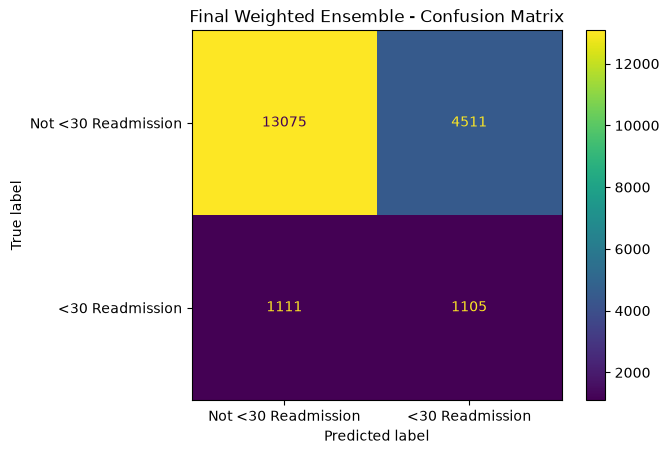

In [117]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Confusion Matrix
cm_final = confusion_matrix(
    y_test_group,
    final_test_pred
)

print("Final Confusion Matrix:")
print(cm_final)

print("\nClassification Report:")
print(
    classification_report(
        y_test_group,
        final_test_pred,
        digits=4,
        zero_division=0
    )
)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Not <30 Readmission", "<30 Readmission"]
)

disp.plot(
    values_format="d"
)

plt.title("Final Weighted Ensemble - Confusion Matrix")
plt.show()

### 9.6 Final Model Interpretation

The final weighted ensemble correctly identified 1,105 patients who were readmitted within 30 days, while 1,111 positive cases were missed.

The model achieved a Recall of `0.4986` for the minority `<30-day readmission` class, meaning that approximately half of the actual early-readmission cases were detected.

The relatively low Precision (`0.1968`) indicates that the model also produced a substantial number of false-positive alerts.

This represents the expected Precision-Recall trade-off for the imbalanced readmission prediction problem.

Because the primary goal is to identify patients at higher risk of early readmission, Recall, PR-AUC, and F1-score are considered more informative than Accuracy alone.

### 9.7 Final Results Summary

The final comparison highlights the improvement from the baseline XGBoost model to the optimized weighted ensemble.

The final model was selected using Validation performance only, while the Test set was reserved for unbiased final evaluation.

In [118]:
final_summary = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Final Weighted Ensemble"
    ],
    "Precision": [
        0.2230,
        0.1968
    ],
    "Recall": [
        0.4030,
        0.4986
    ],
    "F1": [
        0.2870,
        0.2822
    ],
    "ROC-AUC": [
        0.6750,
        0.6768
    ],
    "PR-AUC": [
        0.2380,
        0.2390
    ]
})

display(final_summary)

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Baseline XGBoost,0.2230,0.4030,0.2870,0.6750,0.238
1,Final Weighted Ensemble,0.1968,0.4986,0.2822,0.6768,0.239


### 10. Deployment

The final deployment bundle contains all components required to reproduce predictions from the selected weighted ensemble.

The deployed model consists of:

- Tuned LightGBM model
- XGBoost model trained on engineered features
- Original preprocessing pipeline for LightGBM
- Engineered-feature preprocessing pipeline for XGBoost
- Ensemble weights:
  - LightGBM = `0.60`
  - XGBoost = `0.40`
- Final classification threshold = `0.13`

All preprocessing objects and model parameters are saved together to ensure consistent inference on new patient records.

In [119]:
[var for var in globals().keys() if "preprocess" in var.lower()]

['preprocessor_fe']

In [121]:
required_vars = [
    "encoder_group",
    "scaler_group",
    "numeric_features_group",
    "categorical_features_group",
    "preprocessor_fe",
    "best_lgbm_tuned",
    "xgb_fe"
]

for var in required_vars:
    print(var, "->", var in globals())

encoder_group -> True
scaler_group -> True
numeric_features_group -> True
categorical_features_group -> True
preprocessor_fe -> True
best_lgbm_tuned -> True
xgb_fe -> True


In [122]:
import joblib

final_ensemble_bundle = {
    # Models
    "lightgbm_model": best_lgbm_tuned,
    "xgboost_fe_model": xgb_fe,

    # Original preprocessing objects
    "encoder_group": encoder_group,
    "scaler_group": scaler_group,
    "numeric_features_group": numeric_features_group,
    "categorical_features_group": categorical_features_group,

    # Engineered-feature preprocessing
    "engineered_preprocessor": preprocessor_fe,

    # Feature engineering metadata
    "engineered_feature_names": new_features,

    # Ensemble configuration
    "lightgbm_weight": 0.60,
    "xgboost_weight": 0.40,
    "threshold": 0.13,

    # Original input columns
    "original_input_columns": X_train_group.columns.tolist()
}

joblib.dump(
    final_ensemble_bundle,
    "final_readmission_ensemble.joblib"
)

print("Final ensemble bundle saved successfully.")
print("File: final_readmission_ensemble.joblib")

Final ensemble bundle saved successfully.
File: final_readmission_ensemble.joblib
